# Credit Score Classification - Machine Learning HW1

Davide De Blasio  
November 19, 2025

## Project Overview

This project performs comprehensive data analysis and preprocessing on a [Credit Score Classification Dataset (Kaggle)](https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data)

**Target Variable:** Credit Score (Poor, Standard, Good)

## 1. Environment Setup

Import all necessary libraries for data manipulation, visualization, statistical analysis, and machine learning preprocessing.

In [261]:
# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Statistical testing
import pingouin as pg
from scipy import stats

# Preprocessing and modeling
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### Color Palette Definition

Define a consistent Seaborn color palette to ensure uniform color mapping across all visualizations throughout the notebook.

In [ ]:
# Define consistent color palette for all visualizations
PALETTE = sns.color_palette("hls", 10)

# Define explicit class-to-color mapping for Credit Score
CREDIT_SCORE_COLORS = {
    'Poor': PALETTE[0],      
    'Standard': PALETTE[1],  
    'Good': PALETTE[2]    
}

# Helper function to map Credit Score categories to colors in correct order
def get_credit_score_palette(categories):
    return [CREDIT_SCORE_COLORS[cat] for cat in categories]

sns.set_palette(PALETTE)

✓ Color palette initialized: 'bright' with 10 distinct colors
✓ Credit Score color mapping:
  - Poor: (0.86, 0.3712, 0.33999999999999997)
  - Standard: (0.86, 0.6832, 0.33999999999999997)
  - Good: (0.7247999999999999, 0.86, 0.33999999999999997)


## 2. Data Acquisition

Download the Credit Score Classification dataset from Kaggle and load it into a DataFrame for analysis.

In [263]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("parisrohan/credit-score-classification")
df = pd.read_csv(path + "/train.csv", low_memory=False)

print(f"\nDataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
df.head() # Preview the first rows


Dataset Dimensions: 100000 rows × 28 columns


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

Examine dataset structure, data types, and basic properties to understand the data before analysis.

In [264]:
# Display data types for each column
print("Data Types:")
print(df.dtypes)

Data Types:
ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score    

In [265]:
# Show dataset information including non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [266]:
# Count unique values per column
print("Unique Values per Column:")
print(df.nunique())

Unique Values per Column:
ID                          100000
Customer_ID                  12500
Month                            8
Name                         10139
Age                           1788
SSN                          12501
Occupation                      16
Annual_Income                18940
Monthly_Inhand_Salary        13235
Num_Bank_Accounts              943
Num_Credit_Card               1179
Interest_Rate                 1750
Num_of_Loan                    434
Type_of_Loan                  6260
Delay_from_due_date             73
Num_of_Delayed_Payment         749
Changed_Credit_Limit          4384
Num_Credit_Inquiries          1223
Credit_Mix                       4
Outstanding_Debt             13178
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          14950
Amount_invested_monthly      91049
Payment_Behaviour                7
Monthly_Balance              98792
Credit_Score                 

In [267]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


### 3.2 Feature Descriptions

Overview of dataset columns and their meanings.

**Key Features:**
- **ID**: Unique identification of an entry
- **Customer_ID**: Unique identification of a person
- **Month**: Month of the year
- **Name**: Name of a person
- **Age**: Age of the person
- **SSN**: Social security number
- **Occupation**: Occupation of the person
- **Annual_Income**: Annual income of the person
- **Monthly_Inhand_Salary**: Monthly base salary
- **Num_Bank_Accounts**: Number of bank accounts held
- **Num_Credit_Card**: Number of credit cards held
- **Interest_Rate**: Interest rate on credit card
- **Num_of_Loan**: Number of loans taken
- **Type_of_Loan**: Types of loans taken
- **Delay_from_due_date**: Average days delayed from payment date
- **Num_of_Delayed_Payment**: Average number of payments delayed
- **Changed_Credit_Limit**: Percentage change in credit card limit
- **Num_Credit_Inquiries**: Number of credit card inquiries
- **Credit_Mix**: Classification of mix of credits
- **Outstanding_Debt**: Remaining debt to be paid (USD)
- **Credit_Utilization_Ratio**: Utilization ratio of credit card
- **Credit_History_Age**: Age of credit history
- **Payment_of_Min_Amount**: Whether minimum amount was paid
- **Total_EMI_per_month**: Monthly EMI payments (USD)
- **Amount_invested_monthly**: Monthly investment amount (USD)
- **Payment_Behaviour**: Payment behavior of customer
- **Monthly_Balance**: Monthly balance amount (USD)
- **Credit_Score**: Bracket of credit score (Poor, Standard, Good) - **TARGET**

### 3.3 Missing Values Analysis

Visualize and quantify missing data to guide the cleaning strategy.

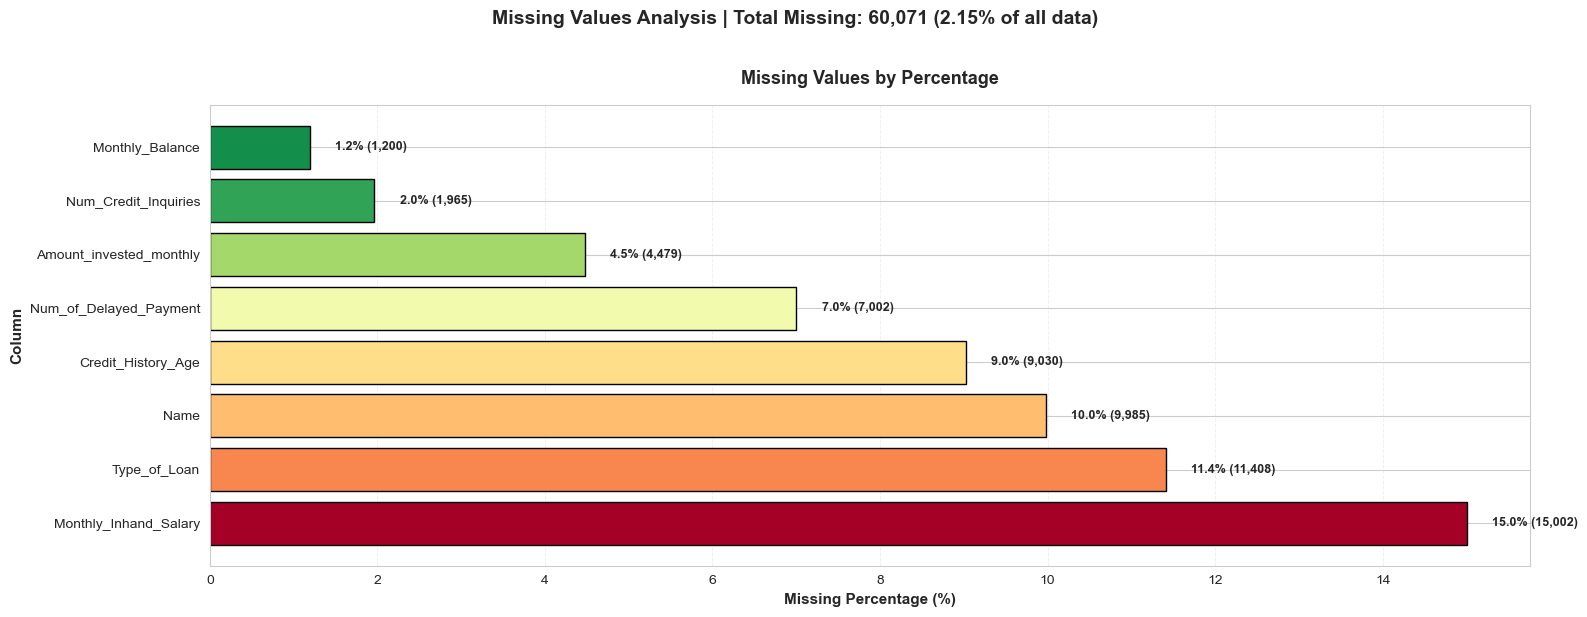


Missing Values Summary:
Total missing values: 60,071
Percentage of total data: 2.15%
Columns with missing values: 8 out of 28


In [268]:
# Calculate and visualize missing values
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Create DataFrame with missing value statistics
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

# Create horizontal bar chart
colors = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax.barh(missing_df['Column'], missing_df['Percentage'], color=colors, edgecolor='black', linewidth=1)

ax.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Column', fontsize=11, fontweight='bold')
ax.set_title('Missing Values by Percentage', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

# Annotate bars with percentage and count
for bar, pct, count in zip(bars, missing_df['Percentage'], missing_df['Count']):
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}% ({int(count):,})', 
            ha='left', va='center', fontsize=9, fontweight='bold')

# Add overall summary
total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total Missing: {int(total_missing):,} ({overall_pct:.2f}% of all data)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("\nMissing Values Summary:")
print(f"Total missing values: {int(total_missing):,}")
print(f"Percentage of total data: {overall_pct:.2f}%")
print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")

### 3.4 Statistical Summaries

Generate descriptive statistics for numerical and categorical features.

In [269]:
# Statistical summary for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [270]:
# Statistical summary for categorical features
df.describe(exclude=np.number).T

,count,unique,top,freq
ID,100000,100000,0x1602,1
Customer_ID,100000,12500,CUS_0xd40,8
Month,100000,8,January,12500
Name,90015,10139,Langep,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,36585.12,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


### 3.5 Target Variable Distribution

Visualize and analyze the distribution of Credit Score classes (target variable).

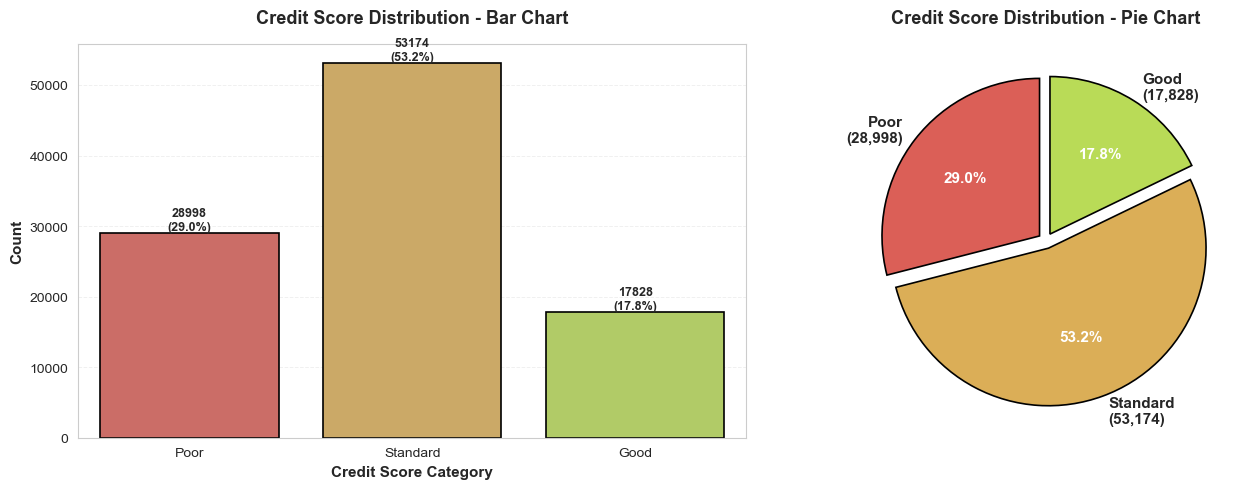


Normalized Credit Score Distribution:
Credit_Score
Good        0.17828
Poor        0.28998
Standard    0.53174
Name: proportion, dtype: float64


In [271]:
# Visualize Credit Score distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Use consistent color palette with explicit class-to-color mapping
credit_order = ['Poor', 'Standard', 'Good']
credit_counts = df['Credit_Score'].value_counts()[credit_order]
total = len(df['Credit_Score'])

# Get colors in the correct order for the plot
colors = get_credit_score_palette(credit_order)

# Bar chart
sns.countplot(data=df, x='Credit_Score', ax=ax1, palette=colors, 
              edgecolor='black', linewidth=1.2, order=credit_order)
ax1.set_title('Credit Score Distribution - Bar Chart', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Credit Score Category', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

# Annotate bars
for patch in ax1.patches:
    height = patch.get_height()
    percentage = (height / total) * 100
    ax1.text(patch.get_x() + patch.get_width()/2., height, 
             f'{int(height)}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart
explode = (0.05, 0.05, 0.05)
wedges, texts, autotexts = ax2.pie(credit_counts, labels=credit_order, autopct='%1.1f%%', 
                                     colors=colors, explode=explode, startangle=90, 
                                     textprops={'fontsize': 10, 'fontweight': 'bold'}, 
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})

# Style pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    
for label, count in zip(texts, credit_counts):
    label.set_fontsize(11)
    label.set_fontweight('bold')
    label.set_text(f'{label.get_text()}\n({count:,})')
    
ax2.set_title('Credit Score Distribution - Pie Chart', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()


print("\nNormalized Credit Score Distribution:")
print(df['Credit_Score'].value_counts(normalize=True).sort_index())

### 3.6 Categorical Features Distribution

Visualize the distribution of key categorical features to understand their value distributions.

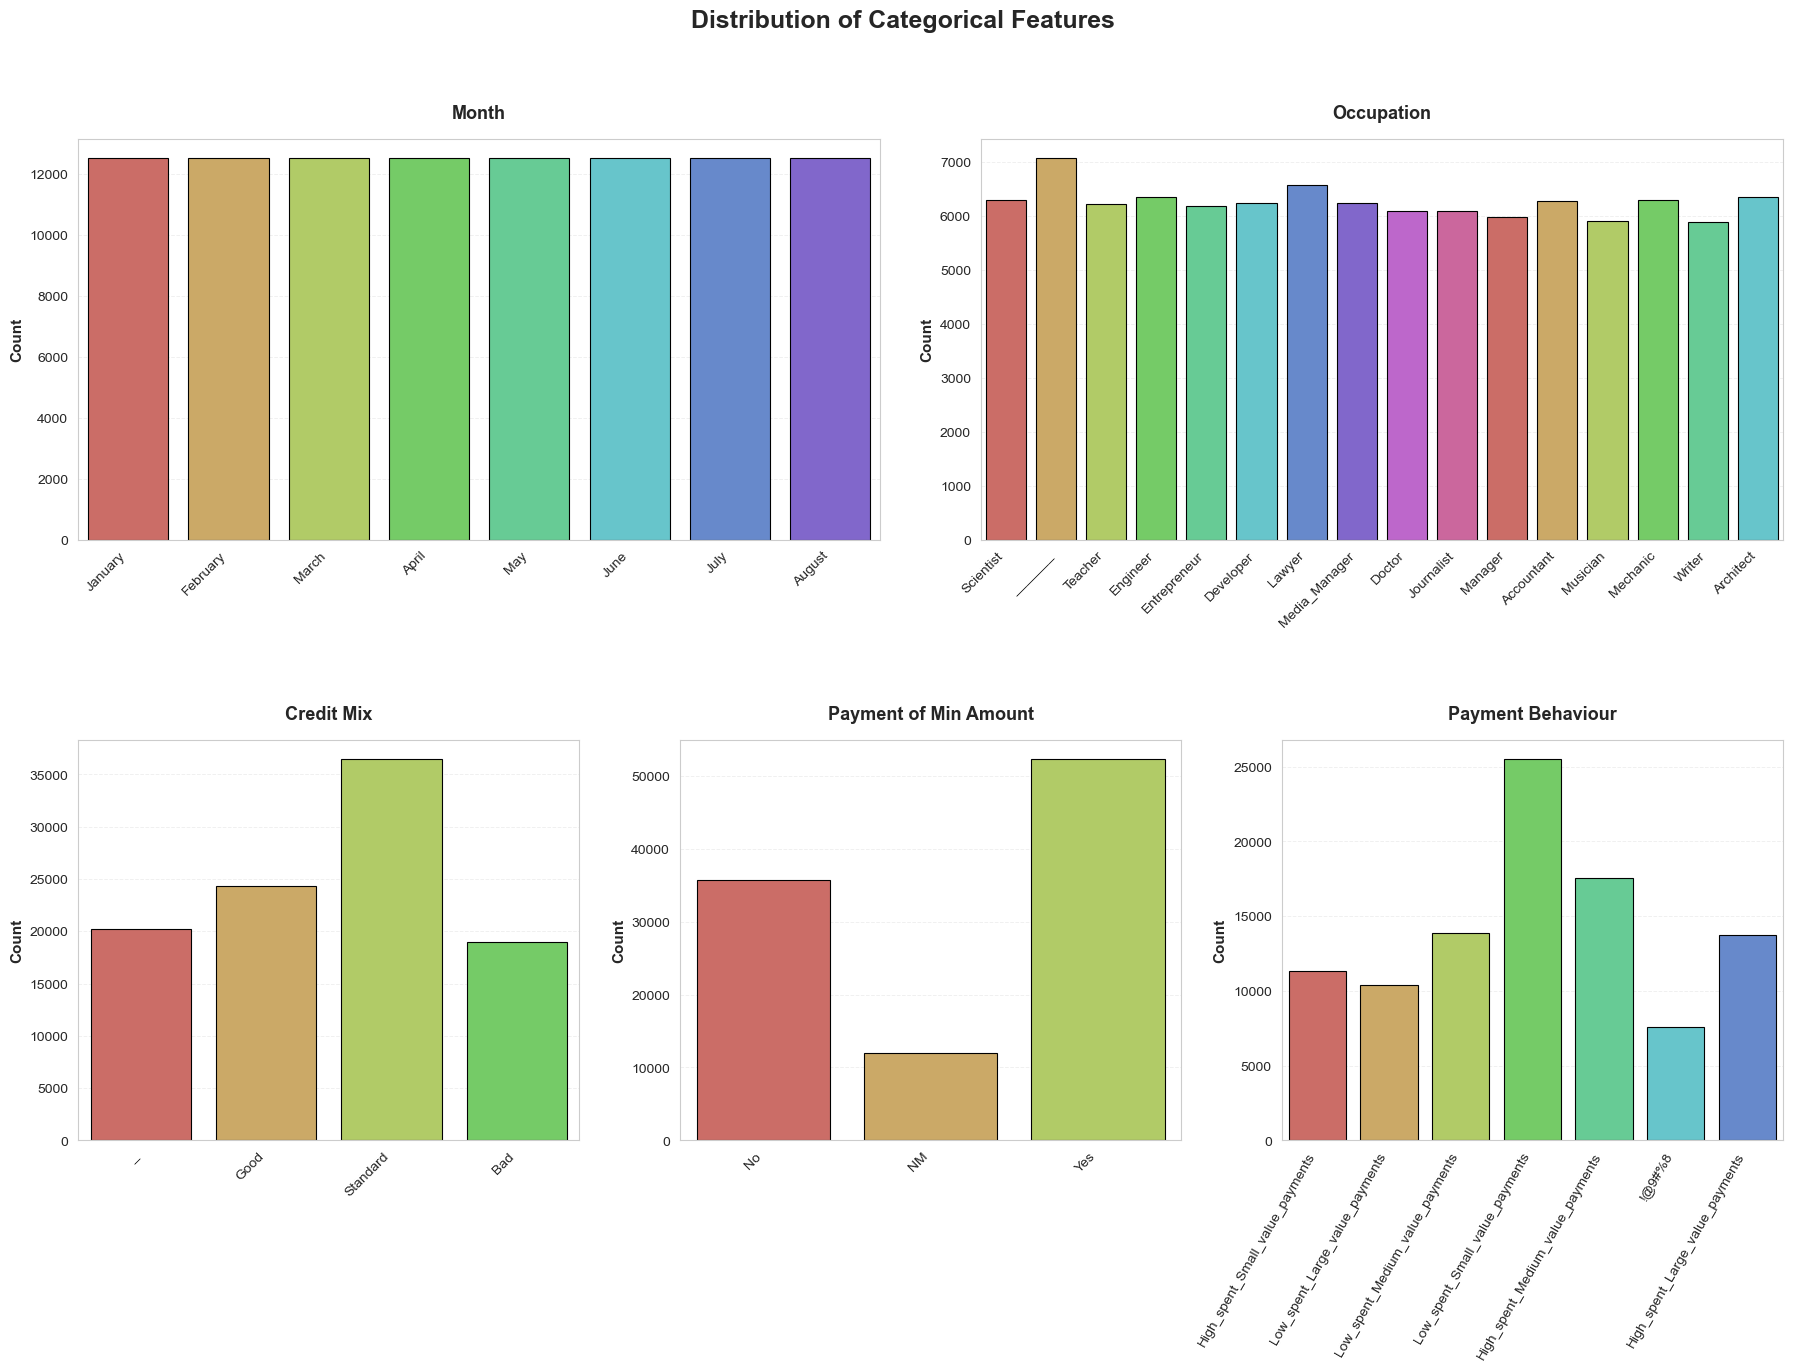

In [272]:
# Visualize categorical features distribution
columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

fig = plt.figure(figsize=(22, 13))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.5)

ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
axes_list = [ax1, ax2, ax3, ax4, ax5]

fig.suptitle('Distribution of Categorical Features', fontsize=18, fontweight='bold', y=0.98)

for idx, col in enumerate(columns):
    ax = axes_list[idx]
    sns.countplot(data=df, x=col, ax=ax, palette=PALETTE, edgecolor='black', linewidth=0.8)
    ax.set_title(f'{col.replace("_", " ")}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    
    # Rotate x labels for readability
    if col == 'Payment_Behaviour':
        ax.tick_params(axis='x', rotation=60, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
            label.set_fontweight('medium')
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 3.7 Numerical Features Distribution

Visualize the distribution of selected numerical features using histograms and KDE plots.

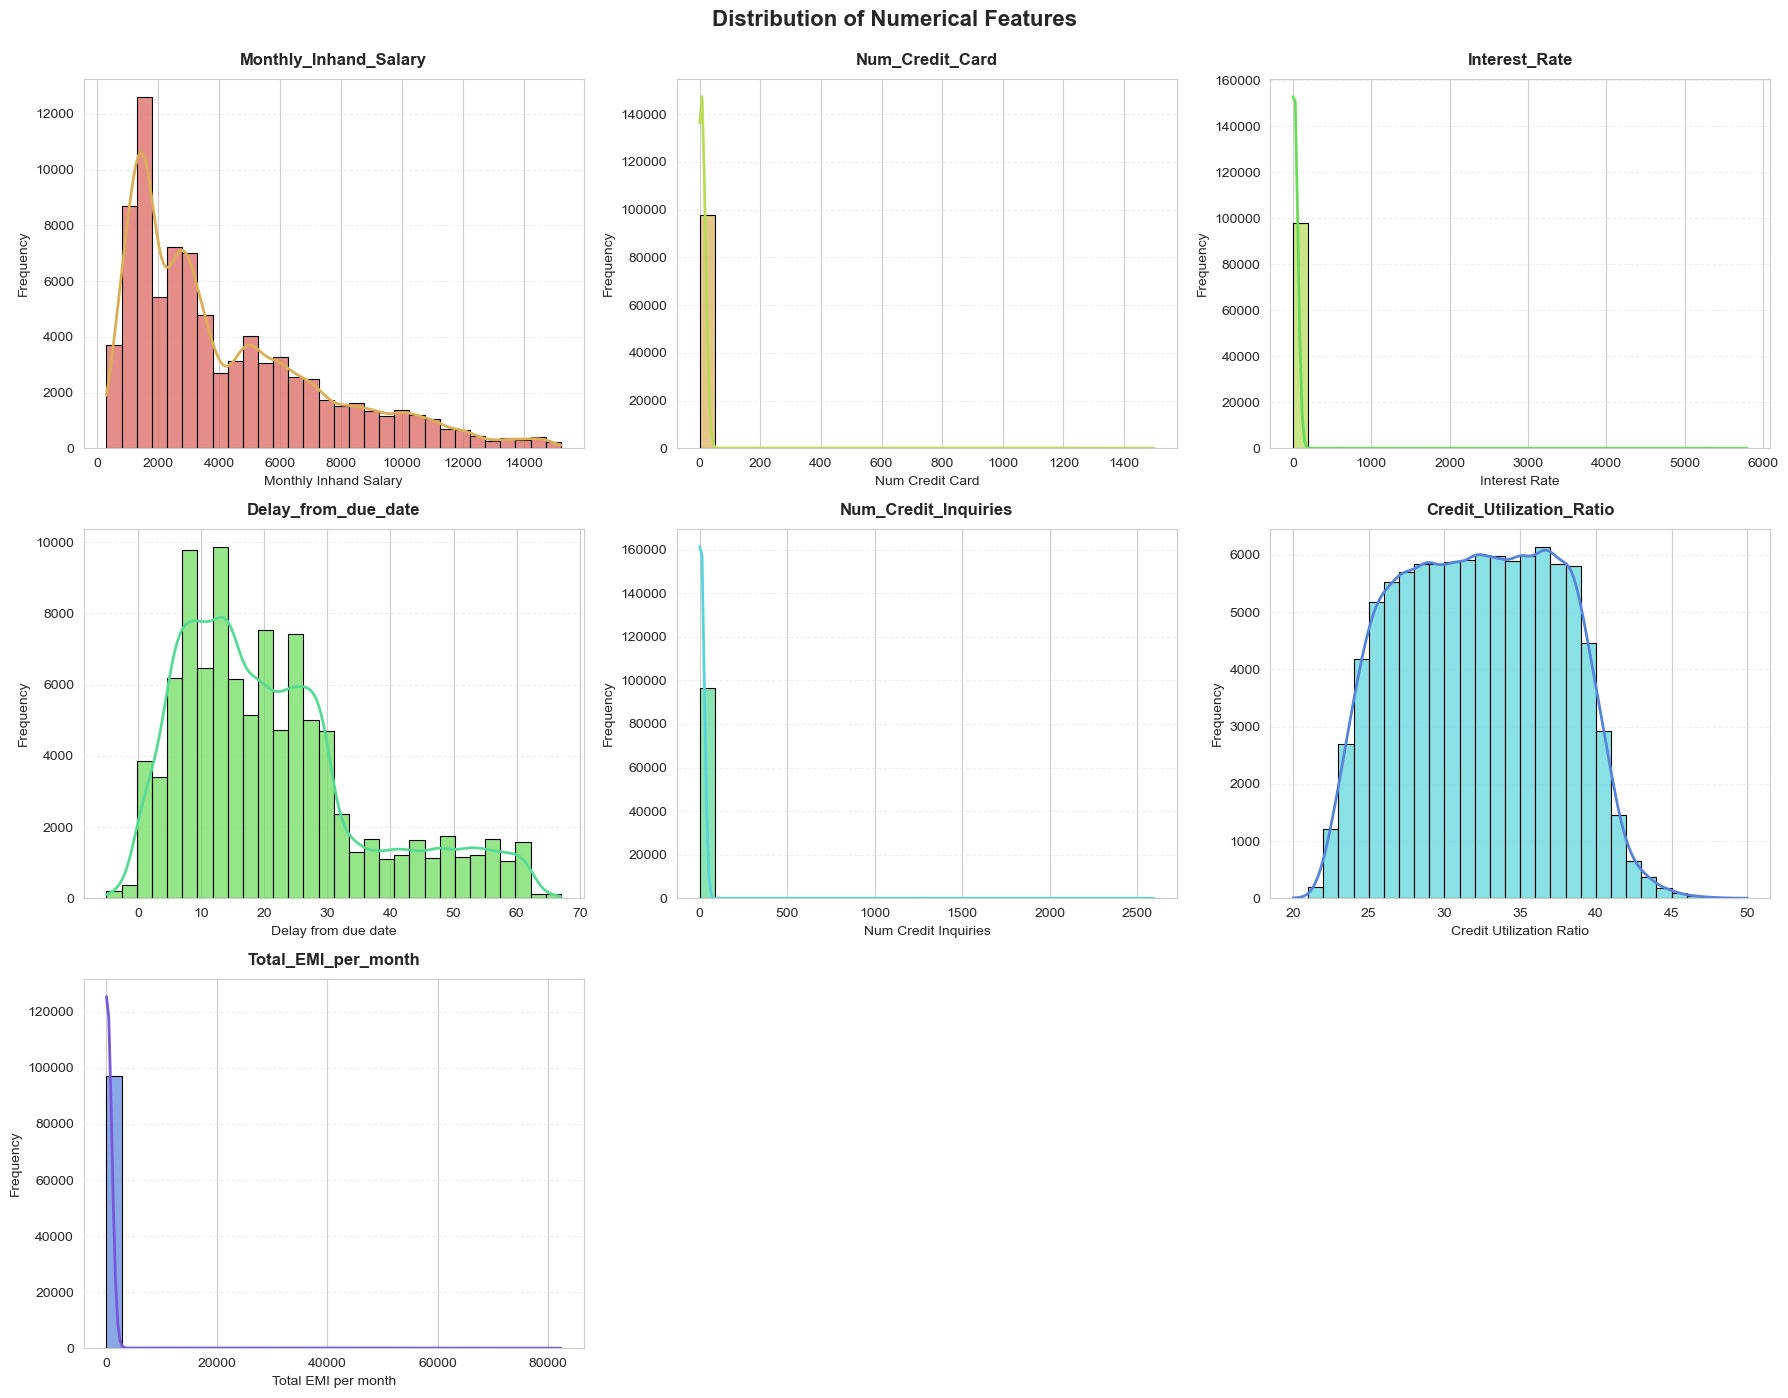

In [273]:
# Visualize numerical features using histograms with KDE
columns = ['Monthly_Inhand_Salary', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date',
           'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, col in enumerate(columns):
    # Use different color for each feature from the palette
    feature_color = PALETTE[idx % len(PALETTE)]
    kde_color = PALETTE[(idx + 1) % len(PALETTE)]
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color=feature_color, 
                 edgecolor='black', linewidth=0.8, bins=30, alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel(col.replace('_', ' '), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Style KDE line with different color
    for line in axes[idx].lines:
        line.set_color(kde_color)
        line.set_linewidth(2)

# Hide unused subplots
for idx in range(len(columns), 9):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 3.8 Type of Loan Analysis

Examine the Type_of_Loan feature to understand loan diversity.

In [274]:
# Display top 10 loan types
print("Type of Loan - Top 10 Values:")
df['Type_of_Loan'].value_counts().head(10)

Type of Loan - Top 10 Values:


Type_of_Loan
Not Specified                      1408
Credit-Builder Loan                1280
Personal Loan                      1272
Debt Consolidation Loan            1264
Student Loan                       1240
Payday Loan                        1200
Mortgage Loan                      1176
Auto Loan                          1152
Home Equity Loan                   1136
Personal Loan, and Student Loan     320
Name: count, dtype: int64

### 3.9 Initial Observations

**Key Findings from EDA:**
1. **ID, Name, SSN**: Not useful for prediction (should be dropped)
2. **Data Type Issues**: Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Amount_invested_monthly, Outstanding_Debt, Monthly_Balance are numerical but stored as categorical (need fixing)
3. **Placeholder Values**: Occupation and Credit_Mix have "__" values that need replacement
4. **Data Quality Issues**:
   - Data contains outliers
   - Num_Credit_Card has zeros
   - Num_Bank_Accounts contains negative values
5. **Feature Engineering Needed**:
   - Type_of_Loan needs to be split into multiple binary columns
   - Credit_History_Age format needs conversion to months
   - Payment_of_Min_Amount has 'NM' values
   - Payment_Behaviour and Credit_Mix need cleaning
6. **Target Imbalance**: Credit Score distribution is imbalanced
7. **Missing Data**: Significant missing values across multiple columns

## 4. Data Cleaning

### 4.1 Drop Irrelevant Columns

Remove ID, Name, and SSN columns as they don't contribute to prediction.

In [275]:
# Drop ID, Name, and SSN columns (not useful for prediction)
cols_to_drop = ['ID', 'Name', 'SSN']
df.drop(cols_to_drop, axis=1, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")

Dropped columns: ['ID', 'Name', 'SSN']
New shape: (100000, 25)


### 4.2 Fix Data Type Issues

Convert numerical columns incorrectly stored as strings by removing underscores and converting to float.

In [276]:
# Remove underscores and convert to float
cols_to_fix = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in cols_to_fix:
    df[col] = df[col].str.replace('_', '')
    try:
        df[col] = df[col].astype('float')
    except Exception:
        continue

print("Fixed data types for numerical columns:")
df[cols_to_fix].info()

Fixed data types for numerical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  float64
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  float64
 3   Num_of_Delayed_Payment   92998 non-null   float64
 4   Changed_Credit_Limit     100000 non-null  object 
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  95521 non-null   float64
 7   Monthly_Balance          98800 non-null   float64
dtypes: float64(7), object(1)
memory usage: 6.1+ MB


In [277]:
# Fix Changed_Credit_Limit empty strings
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('', np.nan)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype('float')

print("Fixed Changed_Credit_Limit column")

Fixed Changed_Credit_Limit column


In [278]:
# Verify data type fixes
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


### 4.3 Handle Negative Values

Replace negative values with NaN in columns where negatives are invalid.

In [279]:
# Replace negative values with NaN
columns_to_fix = ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit']

df[columns_to_fix] = df[columns_to_fix].applymap(lambda x: np.nan if x < 0 else x)

print("Replaced negative values with NaN")
print("\nDescriptive statistics after fixing:")
df[cols_to_fix].describe().T

Replaced negative values with NaN

Descriptive statistics after fixing:


,count,mean,std,min,25%,50%,75%,max
Age,99114.0,1.161084e+02,6.868613e+02,1.400000e+01,25.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Num_of_Loan,96124.0,7.163622e+00,6.031492e+01,0.000000e+00,2.000000,3.000000,5.000000,1.496000e+03
Num_of_Delayed_Payment,92354.0,3.115052e+01,2.268022e+02,0.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,96323.0,1.059904e+01,6.639966e+00,0.000000e+00,5.570000,9.520000,15.010000,3.697000e+01
Outstanding_Debt,100000.0,1.426220e+03,1.155129e+03,2.300000e-01,566.072500,1166.155000,1945.962500,4.998070e+03
Amount_invested_monthly,95521.0,6.374130e+02,2.043319e+03,0.000000e+00,74.534002,135.925682,265.731733,1.000000e+04
Monthly_Balance,98800.0,-3.036437e+22,3.181295e+24,-3.333333e+26,270.092209,336.719190,470.220186,1.602041e+03


### 4.4 Correlation Analysis

Analyze correlations between numerical features after initial cleaning.

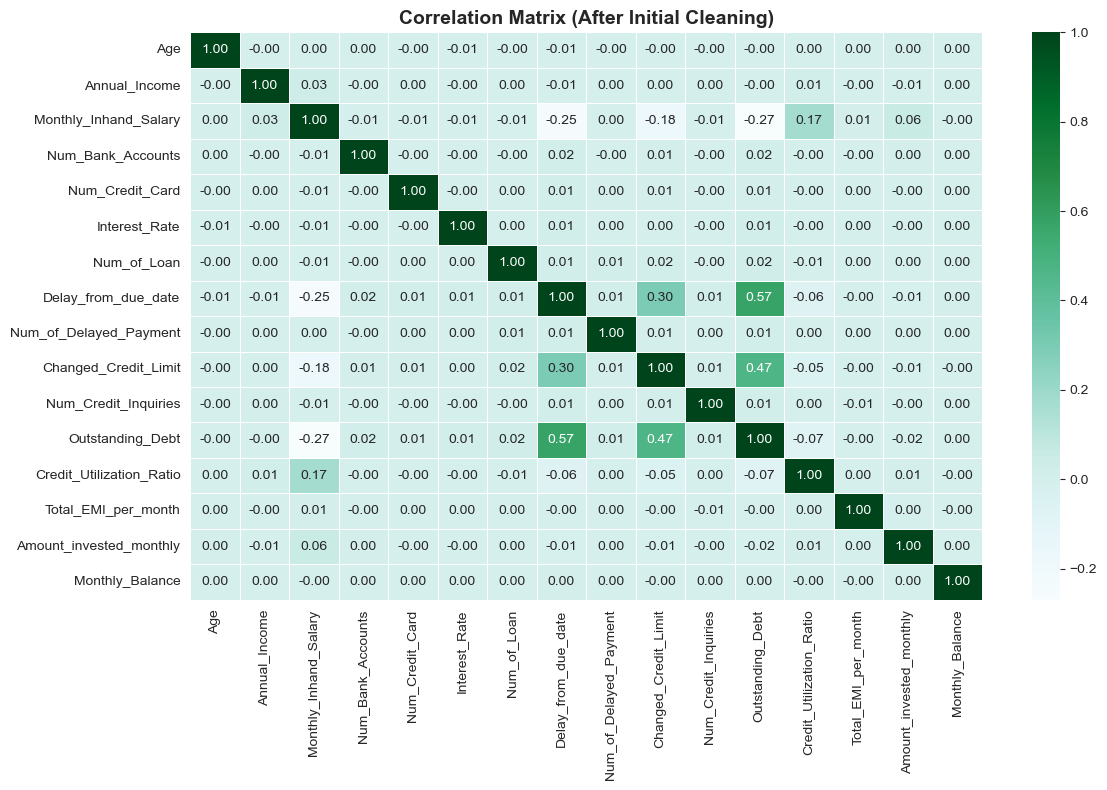

In [280]:
# Compute correlation matrix
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix (After Initial Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Categorical Features Review

Examine categorical features to identify data quality issues.

In [281]:
# Review categorical features
cat_data = df[df.select_dtypes(include=['object']).columns]
print("Categorical features:")
cat_data.head()

Categorical features:


,Customer_ID,Month,Occupation,Type_of_Loan,Credit_Mix,Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,CUS_0xd40,January,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",_,22 Years and 1 Months,No,High_spent_Small_value_payments,Good
1,CUS_0xd40,February,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,NaN,No,Low_spent_Large_value_payments,Good
2,CUS_0xd40,March,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 3 Months,No,Low_spent_Medium_value_payments,Good
3,CUS_0xd40,April,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 4 Months,No,Low_spent_Small_value_payments,Good
4,CUS_0xd40,May,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 5 Months,No,High_spent_Medium_value_payments,Good


In [282]:
# Value counts for all categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col} value counts:')
    print(df[col].value_counts())
    print('-' * 50)


Customer_ID value counts:
Customer_ID
CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
             ..
CUS_0x2eb4    8
CUS_0x7863    8
CUS_0x9d89    8
CUS_0xc045    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64
--------------------------------------------------

Month value counts:
Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
--------------------------------------------------

Occupation value counts:
Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64
------------------------------

### 4.6 Feature-Specific Cleaning

Apply specific cleaning transformations to individual features.

In [283]:
# Convert Credit_History_Age from "Years and Months" format to total months
def convert_to_months(value):
    """Convert Credit_History_Age string to integer months."""
    if pd.isnull(value):
        return value
    years = int(value.split(' ')[0])
    months = int(value.split(' ')[3])
    return years * 12 + months

df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_to_months).astype(float)
print("Converted Credit_History_Age to months")

Converted Credit_History_Age to months


In [284]:
# Standardize Payment_of_Min_Amount values
df['Payment_of_Min_Amount'].replace('NM', 'No', inplace=True)
print("Standardized Payment_of_Min_Amount values")

Standardized Payment_of_Min_Amount values


In [285]:
# Replace placeholder values with NaN
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

print("Replaced placeholder values with NaN")

Replaced placeholder values with NaN


In [286]:
# Convert Customer_ID from hexadecimal to integer
df['Customer_ID'] = df['Customer_ID'].apply(lambda x: int(x[4:], 16))
print("Transformed Customer_ID from hexadecimal to integer")

Transformed Customer_ID from hexadecimal to integer


## 5. Missing Value Treatment

### 5.1 Post-Cleaning Missing Values Analysis

Re-assess missing values after data cleaning to plan imputation strategy.

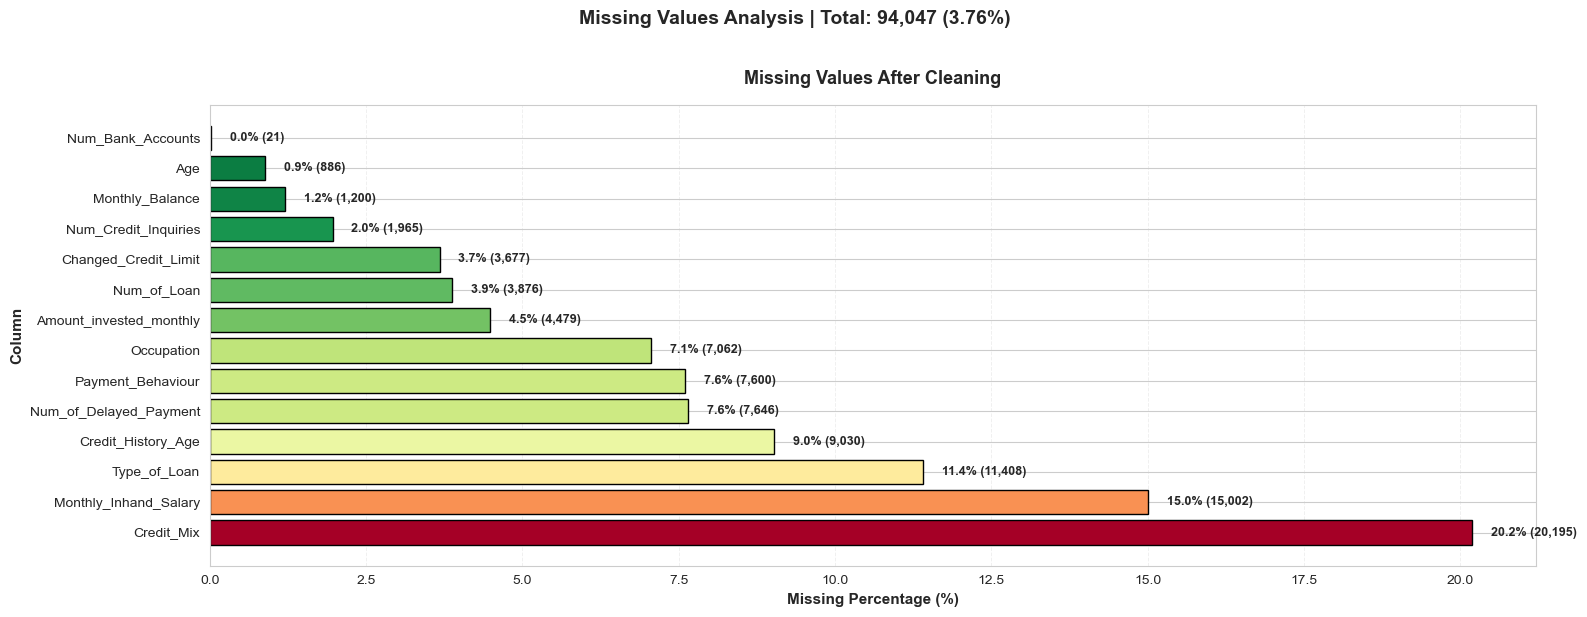


Columns with missing values: 14 out of 25


In [287]:
# Visualize missing values after cleaning to verify improvements
fig, ax1 = plt.subplots(1,1, figsize=(16, 6))

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values After Cleaning', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

# Annotate each bar with percentage and count of missing values
for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{pct:.1f}% ({int(count):,})', ha='left', va='center', fontsize=9, fontweight='bold')

total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total: {int(total_missing):,} ({overall_pct:.2f}%)', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print(f"\nColumns with missing values: {len(missing_df)} out of {df.shape[1]}")

In [288]:
# Check missing value counts for each column after cleaning
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:
Age                          886
Occupation                  7062
Monthly_Inhand_Salary      15002
Num_Bank_Accounts             21
Num_of_Loan                 3876
Type_of_Loan               11408
Num_of_Delayed_Payment      7646
Changed_Credit_Limit        3677
Num_Credit_Inquiries        1965
Credit_Mix                 20195
Credit_History_Age          9030
Amount_invested_monthly     4479
Payment_Behaviour           7600
Monthly_Balance             1200
dtype: int64
Age                          886
Occupation                  7062
Monthly_Inhand_Salary      15002
Num_Bank_Accounts             21
Num_of_Loan                 3876
Type_of_Loan               11408
Num_of_Delayed_Payment      7646
Changed_Credit_Limit        3677
Num_Credit_Inquiries        1965
Credit_Mix                 20195
Credit_History_Age          9030
Amount_invested_monthly     4479
Payment_Behaviour           7600
Monthly_Balance             1200
dtype: int64


### 5.2 Imputation Strategy for Categorical Features

Fill missing categorical values using customer-specific mode or global mode as fallback.

In [289]:
# Impute categorical features using customer-specific mode
def fill_categorical(data, col):
    """Fill missing categorical values with customer mode or global mode."""
    missing_idx = data[col][data[col].isnull()].index
    for idx in missing_idx:
        customer_mode = data[col][data['Customer_ID'] == data.iloc[idx]['Customer_ID']].mode()
        if len(customer_mode) > 0 and not pd.isna(customer_mode[0]):
            data.loc[idx, col] = customer_mode[0]
        else:
            data.loc[idx, col] = data[col].mode()[0]
    return data[col]

print("Categorical imputation function defined")

Categorical imputation function defined


In [290]:
# Identify categorical columns with missing values (exclude Type_of_Loan for special handling)
missing_cat_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(include='object').columns.tolist())
missing_cat_cols.discard('Type_of_Loan')

print(f"Categorical columns to impute: {missing_cat_cols}")

Categorical columns to impute: {'Payment_Behaviour', 'Occupation', 'Credit_Mix'}


In [291]:
# Fill categorical missing values using the defined strategy
for col in missing_cat_cols:
    df[col] = fill_categorical(df, col)
    print(f'Filled {col} column')

print("\nCategorical imputation complete!")

Filled Payment_Behaviour column
Filled Occupation column
Filled Occupation column
Filled Credit_Mix column

Categorical imputation complete!
Filled Credit_Mix column

Categorical imputation complete!


### 5.3 Imputation Strategy for Numerical Features

Fill missing numerical values using customer-specific median or global median as fallback.

In [292]:
# Impute numerical features using customer-specific median
def fill_numerical(data, col):
    """Fill missing numerical values with customer median or global median."""
    missing_idx = data[col][data[col].isnull()].index
    for idx in missing_idx:
        customer_median = data[col][data['Customer_ID'] == data.iloc[idx]['Customer_ID']].median()
        if not pd.isna(customer_median):
            data.loc[idx, col] = customer_median
        else:
            data.loc[idx, col] = data[col].median()
    return data[col]

print("Numerical imputation function defined")

Numerical imputation function defined


In [293]:
# Identify numerical columns with missing values for imputation
missing_num_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(exclude='object').columns.tolist())

print(f"Numerical columns to impute: {missing_num_cols}")

Numerical columns to impute: {'Monthly_Inhand_Salary', 'Amount_invested_monthly', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Monthly_Balance', 'Num_of_Delayed_Payment', 'Age', 'Num_of_Loan', 'Credit_History_Age', 'Num_Bank_Accounts'}


In [294]:
# Fill numerical missing values using the defined strategy
for col in missing_num_cols:
    df[col] = fill_numerical(df, col)
    print(f'Filled {col} column')

print("\nNumerical imputation complete!")

Filled Monthly_Inhand_Salary column
Filled Amount_invested_monthly column
Filled Amount_invested_monthly column
Filled Changed_Credit_Limit column
Filled Changed_Credit_Limit column
Filled Num_Credit_Inquiries column
Filled Num_Credit_Inquiries column
Filled Monthly_Balance column
Filled Monthly_Balance column
Filled Num_of_Delayed_Payment column
Filled Age column
Filled Num_of_Delayed_Payment column
Filled Age column
Filled Num_of_Loan column
Filled Num_of_Loan column
Filled Credit_History_Age column
Filled Num_Bank_Accounts column

Numerical imputation complete!
Filled Credit_History_Age column
Filled Num_Bank_Accounts column

Numerical imputation complete!


### 5.4 Special Handling for Type_of_Loan

Analyze Type_of_Loan structure to extract all loan types for feature engineering.

In [295]:
# Analyze Type_of_Loan structure and extract all loan types for feature engineering
loan_types = {}
for idx, row in df.iterrows():
    vals = row['Type_of_Loan']
    if pd.isnull(vals): 
        continue
    # Split multiple loan types and count occurrences
    vals = vals.replace('and', '').split(', ')
    for val in vals:
        val = val.strip()
        loan_types[val] = loan_types.get(val, 0) + 1

print("Loan types found:")
for k, v in loan_types.items():
    print(f'{k}: {v}')

Loan types found:
Auto Loan: 37992
Credit-Builder Loan: 40440
Personal Loan: 38888
Home Equity Loan: 39104
Not Specified: 39616
Mortgage Loan: 38936
Student Loan: 38968
Debt Consolidation Loan: 38776
Payday Loan: 40568


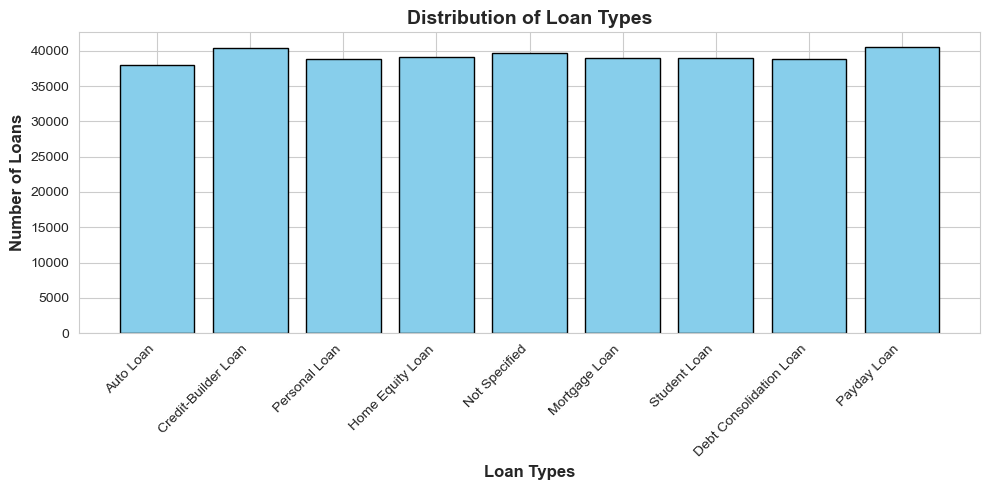

In [296]:
# Visualize loan types distribution to understand feature diversity
plt.figure(figsize=(10, 5))
# Bar plot for loan types
plt.bar(loan_types.keys(), loan_types.values(), color='skyblue', edgecolor='black')
plt.xlabel('Loan Types', fontsize=12, fontweight='bold')
plt.ylabel('Number of Loans', fontsize=12, fontweight='bold')
plt.title('Distribution of Loan Types', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [297]:
# Check percentage of missing Type_of_Loan values to inform next cleaning step
missing_pct = df['Type_of_Loan'].isna().sum() / len(df) * 100
print(f"Percentage of missing Type_of_Loan values: {missing_pct:.2f}%")

Percentage of missing Type_of_Loan values: 11.41%


## 5.5 Drop Remaining NaN Rows

In [298]:
# Drop rows with remaining NaN values (primarily Type_of_Loan) to finalize dataset
shape_before = df.shape
df.dropna(inplace=True)
shape_after = df.shape

print(f"Shape before dropping NaN: {shape_before}")
print(f"Shape after dropping NaN: {shape_after}")
print(f"Rows dropped: {shape_before[0] - shape_after[0]}")

Shape before dropping NaN: (100000, 25)
Shape after dropping NaN: (88592, 25)
Rows dropped: 11408


## 5.6 Verification

In [299]:
# Verify no missing values remain in the cleaned dataset
print("Remaining missing values:")
print(df.isna().sum().sum())
print("\nMissing value treatment complete!")

Remaining missing values:
0

Missing value treatment complete!
0

Missing value treatment complete!


## 6. Feature Engineering

### 6.1 Type_of_Loan Expansion

Create binary columns for each loan type to better represent multiple loan combinations.

In [300]:
# Create binary columns for each loan type for improved feature representation
col_map = {True: 1, False: 0}
for loan_type in list(loan_types.keys()):
    # Mark presence of each loan type in the original string
    df[loan_type] = df['Type_of_Loan'].str.contains(loan_type).map(col_map)

print(f"Created {len(loan_types)} binary loan type columns")
df.info()

Created 9 binary loan type columns
<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               88592 non-null  int64  
 1   Month                     88592 non-null  object 
 2   Age                       88592 non-null  float64
 3   Occupation                88592 non-null  object 
 4   Annual_Income             88592 non-null  float64
 5   Monthly_Inhand_Salary     88592 non-null  float64
 6   Num_Bank_Accounts         88592 non-null  float64
 7   Num_Credit_Card           88592 non-null  int64  
 8   Interest_Rate             88592 non-null  int64  
 9   Num_of_Loan               88592 non-null  float64
 10  Type_of_Loan              88592 non-null  object 
 11  Delay_from_due_date       88592 non-null  int64  
 12  Num_of_Delayed_Payment    88592 non-null  float64
 13  Changed_Credit_Limit      88592

## 6.2 Drop Original Type_of_Loan and 'Not Specified'

In [301]:
# Drop the original Type_of_Loan column and 'Not Specified' column to avoid redundancy
df.drop(['Type_of_Loan', 'Not Specified'], axis=1, inplace=True)

print(f"Dropped Type_of_Loan and 'Not Specified' columns")
print(f"Current shape: {df.shape}")

Dropped Type_of_Loan and 'Not Specified' columns
Current shape: (88592, 32)

Current shape: (88592, 32)


## 6.3 Reorder Columns (Move Target to End)

In [302]:
# Move Credit_Score to the end for consistency in feature ordering
y = df['Credit_Score']
df = df.drop('Credit_Score', axis=1)
df['Credit_Score'] = y

print("Moved Credit_Score to last column")
print(f"Final shape after feature engineering: {df.shape}")

Moved Credit_Score to last column
Final shape after feature engineering: (88592, 32)


# 7. ADVANCED EDA & FEATURE ANALYSIS

## 7.1 Select Numerical Columns for Analysis

In [303]:
# Select numerical columns (excluding Customer_ID and loan type binary columns) for advanced EDA
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-8].tolist()

print(f"Number of numerical columns for analysis: {len(num_cols)}")
print(f"\nNumerical columns: {num_cols}")

Number of numerical columns for analysis: 17

Numerical columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


## 7.2 KDE Plots by Credit Score

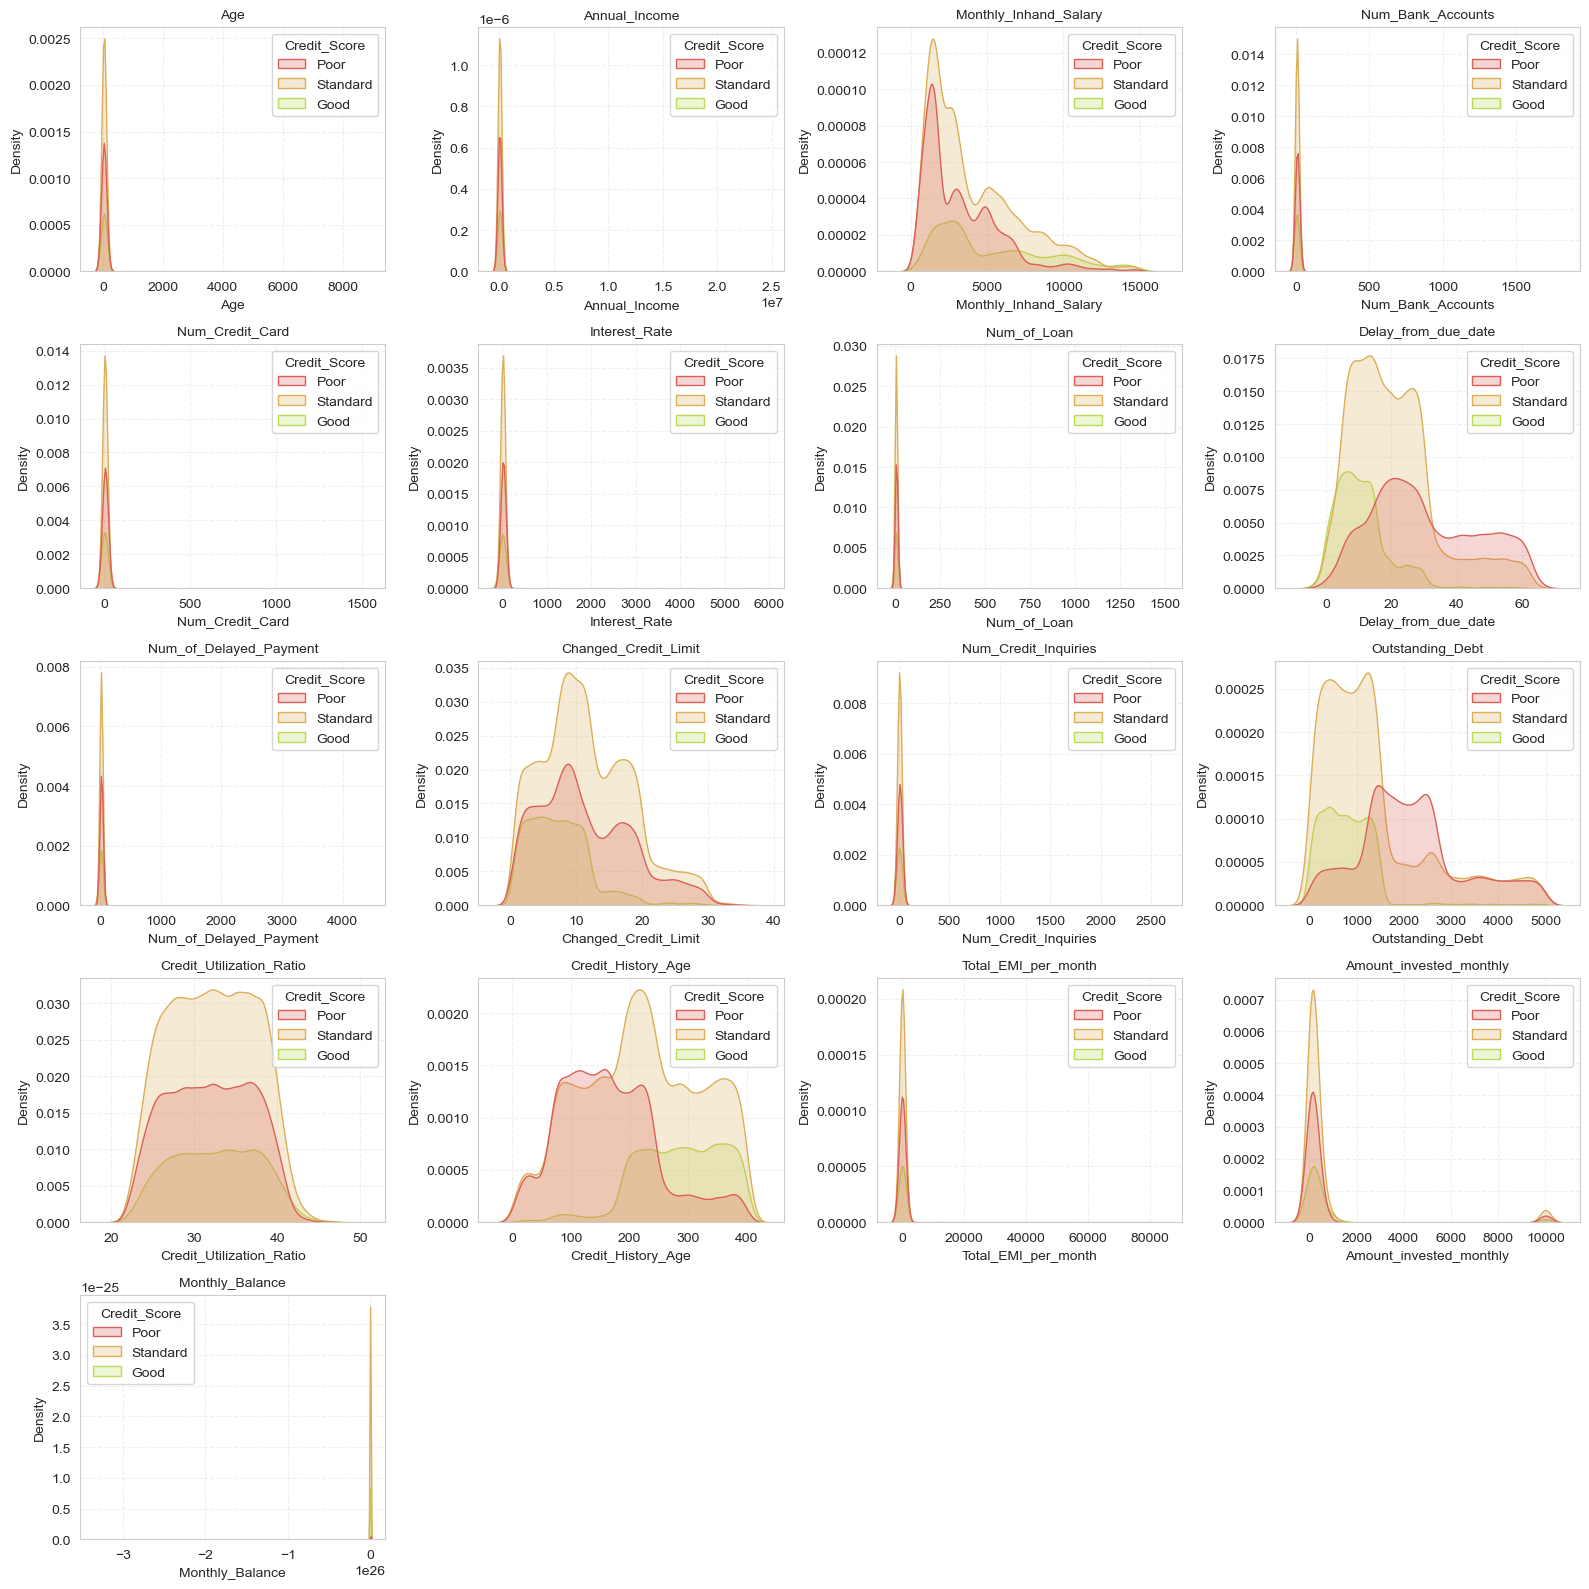

In [304]:
# KDE plots for numerical features colored by Credit Score to visualize class separation
plt.figure(figsize=(16, 16))
for ax, col in enumerate(num_cols):
    plt.subplot(5, 4, ax + 1)
    plt.title(col, fontsize=10)

    # Use dictionary mapping to ensure consistent colors regardless of class ordering
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'], palette=CREDIT_SCORE_COLORS, hue_order=['Poor', 'Standard', 'Good'])
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 7.3 Pairplot for Key Features

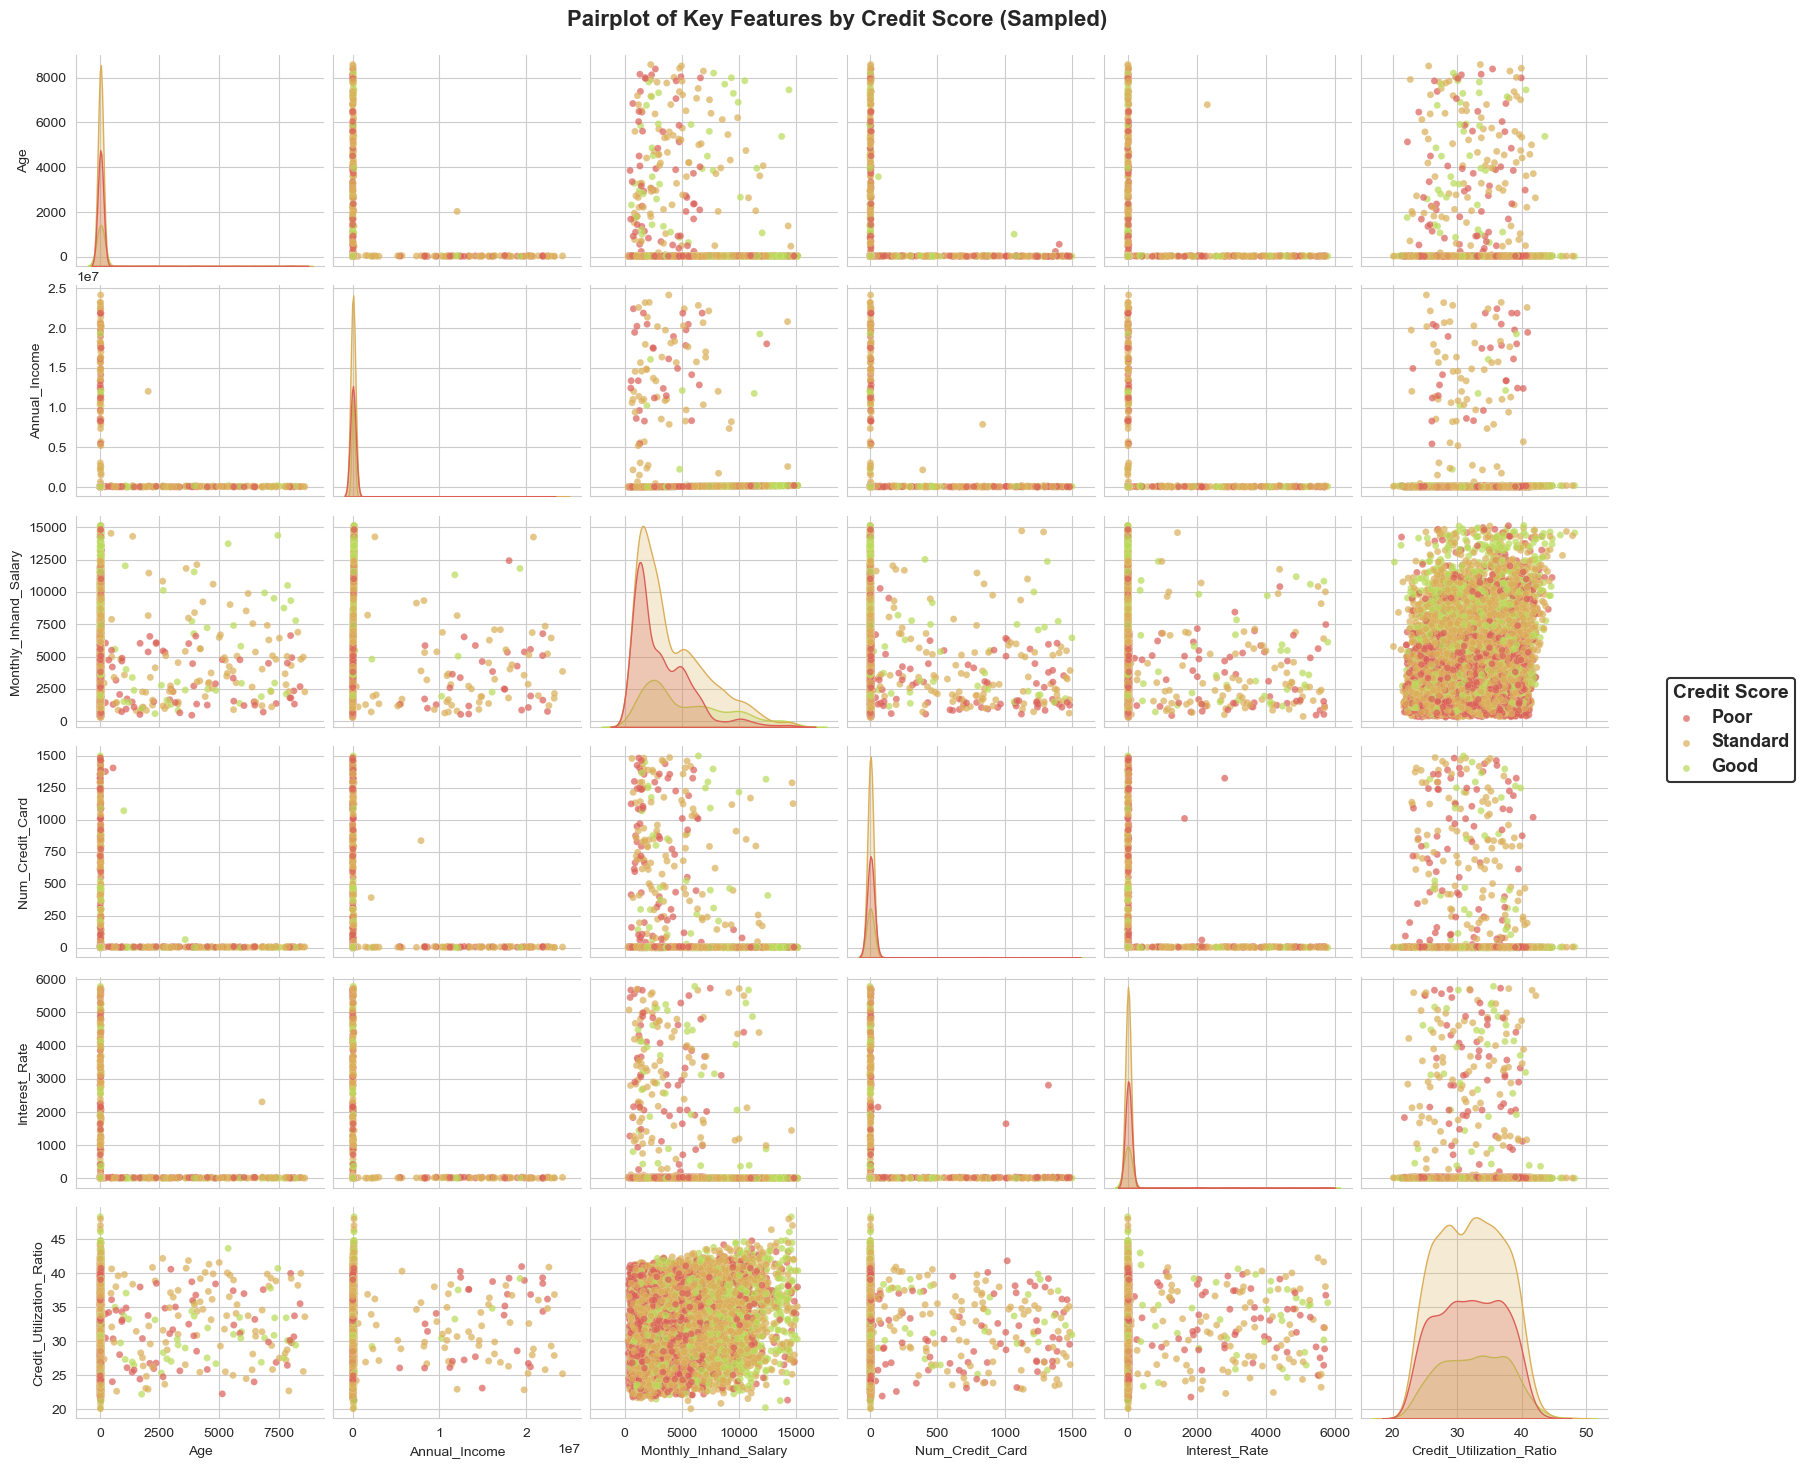


Pairplot generated successfully!
Features analyzed: 6
Target classes: ['Standard' 'Poor' 'Good']
Sample size used: 10000


In [305]:
# Create pairplot for selected key features to visualize relationships and class separation
key_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Credit_Card',
                'Interest_Rate', 'Credit_Utilization_Ratio', 'Credit_Score']

pairplot_df = df[key_features].dropna().copy()

# Sampling limits the number of rows to keep the plot performant on large datasets
sample_size = min(10000, len(pairplot_df))
pairplot_sample = pairplot_df.sample(n=sample_size, random_state=42)

# Use consistent color palette for Credit Score classes with dictionary mapping
g = sns.pairplot(pairplot_sample, hue='Credit_Score', palette=CREDIT_SCORE_COLORS, hue_order=['Poor', 'Standard', 'Good'],
                 plot_kws={'alpha': 0.7, 's': 25, 'edgecolor': 'white', 'linewidth': 0.1}, 
                 diag_kind='kde', height=2.5, aspect=1)

# Move legend outside and customize for better visibility
g._legend.remove()  # Remove default legend
g.add_legend(title='Credit Score', bbox_to_anchor=(0.98, 0.5), loc='center left')
g._legend.set_frame_on(True)
g._legend.get_frame().set_facecolor('white')
g._legend.get_frame().set_edgecolor('black')
g._legend.get_frame().set_linewidth(1.5)

# Make legend text larger and bold
for text in g._legend.texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

# Make legend title bold and larger
g._legend.get_title().set_fontsize(14)
g._legend.get_title().set_fontweight('bold')

g.figure.subplots_adjust(top=0.95, right=0.95)
g.figure.suptitle('Pairplot of Key Features by Credit Score (Sampled)', y=0.98,
               fontsize=16, fontweight='bold')
plt.show()

print("\nPairplot generated successfully!")
print(f"Features analyzed: {len(key_features) - 1}")
print(f"Target classes: {pairplot_sample['Credit_Score'].unique()}")
print(f"Sample size used: {sample_size}")

## 7.5 Chi-Square Tests for Categorical Independence

In [306]:
# Chi-square test function to assess independence between categorical features and target
def chi_square_test(data, col1, col2='Credit_Score'):
    occ = data[[col1, col2]]
    table = pd.crosstab(index=occ[col1], columns=occ[col2])
    t, p, sd, expected = stats.chi2_contingency(table)
    return t, p

print("Chi-square test function defined")

Chi-square test function defined


In [307]:
# Prepare test dataframe for chi-square analysis of categorical features
q_test_cols = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
test_df = df[q_test_cols].copy()
test_df['Credit_Score'] = df['Credit_Score']

print("Test dataframe prepared")
test_df.head()

Test dataframe prepared


,Month,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,January,Scientist,Good,No,High_spent_Small_value_payments,Good
1,February,Scientist,Good,No,Low_spent_Large_value_payments,Good
2,March,Scientist,Good,No,Low_spent_Medium_value_payments,Good
3,April,Scientist,Good,No,Low_spent_Small_value_payments,Good
4,May,Scientist,Good,No,High_spent_Medium_value_payments,Good


In [308]:
# Perform chi-square tests for all categorical variables to identify significant associations
cols, values, p_values = [], [], []
for col in test_df.columns[:-1].tolist():
    cols.append(col)
    t, p = chi_square_test(test_df, col)
    values.append(round(t, 2))
    p_values.append(round(p, 2))

chi_df = pd.DataFrame({
    'Variable': cols,
    'Chi2_Value': values,
    'P_value': p_values
})

chi_df = chi_df.sort_values(by='Chi2_Value', ascending=False)
chi_df.style.bar('Chi2_Value').background_gradient('Blues', subset='Chi2_Value')

,Variable,Chi2_Value,P_value
2,Credit_Mix,36275.530000,0.000000
3,Payment_of_Min_Amount,15380.350000,0.000000
4,Payment_Behaviour,1442.730000,0.000000
1,Occupation,175.220000,0.000000
0,Month,171.880000,0.000000


## 7.6 ANOVA Tests for Numerical Features

In [309]:
# Drop features with low chi-square values before ANOVA (Month and Occupation)
df.drop(['Month', 'Occupation'], axis=1, inplace=True)

print("Dropped Month and Occupation based on chi-square test results")
print(f"New shape: {df.shape}")

Dropped Month and Occupation based on chi-square test results
New shape: (88592, 30)


In [310]:
# Select numeric features for ANOVA testing to assess their relationship with the target
df_numeric = df.select_dtypes(include=['int', 'float'])
# Remove loan type binary columns for this analysis
cols_to_drop_temp = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
 ]
df_numeric_test = df_numeric.drop(cols_to_drop_temp, axis=1)
# Add Credit_Score column which is required for the boxplots and ANOVA grouping
df_numeric_test['Credit_Score'] = df['Credit_Score']

print(f"Numerical columns for ANOVA: {len(df_numeric_test.columns)}")
print(df_numeric_test.columns.tolist())

Numerical columns for ANOVA: 19
['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score']


In [311]:
# ANOVA test function using Welch's ANOVA to compare means across Credit Score classes
def anova_test(data, col1, col2='Credit_Score'):
    df_test = data[[col1, col2]]
    df_melted = pd.melt(df_test, id_vars=col2, var_name=col1, value_name='value')
    test = pg.welch_anova(data=df_melted, dv='value', between=col2)
    return test

print("ANOVA test function defined")

ANOVA test function defined


In [312]:
# Perform ANOVA tests for all numerical variables to identify features with significant differences
cols, values, p_values = [], [], []
for col in df_numeric_test.columns[:-1]:
    cols.append(col)
    test = anova_test(df, col)
    values.append(round(float(test['F'].values), 2))
    p_values.append(round(float(test['p-unc'].values), 2))

anova_df = pd.DataFrame({
    'Variable': cols,
    'F_Value': values,
    'P_value': p_values
})

anova_df = anova_df.sort_values(by='F_Value', ascending=False)
anova_df.style.bar('F_Value').background_gradient('Blues', subset='F_Value')

,Variable,F_Value,P_value
8,Delay_from_due_date,13121.570000,0.000000
12,Outstanding_Debt,11763.220000,0.000000
14,Credit_History_Age,11195.130000,0.000000
10,Changed_Credit_Limit,3632.120000,0.000000
3,Monthly_Inhand_Salary,2101.910000,0.000000
13,Credit_Utilization_Ratio,73.750000,0.000000
0,Customer_ID,8.910000,0.000000
11,Num_Credit_Inquiries,7.580000,0.000000
16,Amount_invested_monthly,6.280000,0.000000
4,Num_Bank_Accounts,5.520000,0.000000


In [313]:
# Drop features with lowest ANOVA F-values (bottom 3)
cols_to_drop = anova_df['Variable'][-3:].tolist()
df.drop(cols_to_drop, axis=1, inplace=True)

print(f"Dropped features with low ANOVA scores: {cols_to_drop}")
print(f"New shape: {df.shape}")

Dropped features with low ANOVA scores: ['Monthly_Balance', 'Age', 'Total_EMI_per_month']
New shape: (88592, 27)


In [314]:
# Display final columns after feature selection
print("Final columns after statistical feature selection:")
print(df.columns.tolist())

Final columns after statistical feature selection:
['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan', 'Mortgage Loan', 'Student Loan', 'Debt Consolidation Loan', 'Payday Loan', 'Credit_Score']


# 8. OUTLIER DETECTION & TREATMENT

## 8.1 Define Outlier Detection Functions

In [315]:
# Define outlier detection functions using IQR method for robust analysis
def outlier_thresholds(data, col_name):
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    return lower_limit, upper_limit

def check_outlier(data, col_name):
    lower_limit, upper_limit = outlier_thresholds(data, col_name)
    outliers = data[(data[col_name] > upper_limit) | (data[col_name] < lower_limit)]
    percentage_outliers = (len(outliers) / len(data)) * 100
    return outliers.any(axis=None), round(percentage_outliers, 2)

print("Outlier detection functions defined")

Outlier detection functions defined


## 8.2 Outlier Percentage Analysis

In [316]:
# Identify and quantify outliers in all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-8].tolist()
outlier_rows = []
for col in num_cols:
    has_outliers, percentage = check_outlier(df, col)
    outlier_rows.append({
        'Column': col,
        'Has_Outliers': has_outliers,
        'Percentage': percentage
    })
outlier_results = pd.DataFrame(outlier_rows)
outlier_results = outlier_results[outlier_results['Has_Outliers']]
outlier_results = outlier_results[outlier_results['Percentage'] > 1]
outlier_results = outlier_results.sort_values(by='Percentage')

print("Outlier Analysis Results:")
outlier_results

Outlier Analysis Results:


,Column,Has_Outliers,Percentage
2,Num_Bank_Accounts,True,1.31
9,Num_Credit_Inquiries,True,1.64
4,Interest_Rate,True,2.05
3,Num_Credit_Card,True,2.24
1,Monthly_Inhand_Salary,True,2.31
0,Annual_Income,True,2.94
6,Delay_from_due_date,True,3.27
10,Outstanding_Debt,True,3.44
13,Amount_invested_monthly,True,10.49


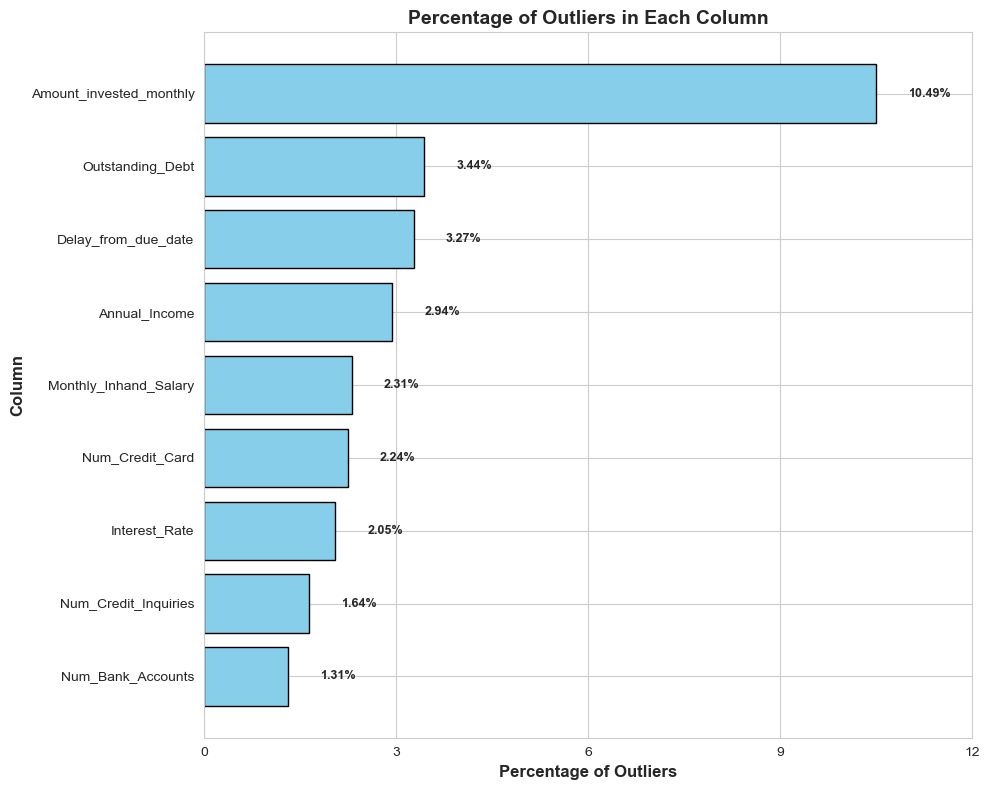

In [ ]:
# Visualize outlier percentages for each column to guide treatment decisions
plt.figure(figsize=(10, 8))
# Bar plot for outlier percentages
bars = plt.barh(outlier_results['Column'], outlier_results['Percentage'], color='skyblue', edgecolor='black')
plt.xlabel('Percentage of Outliers', fontsize=12, fontweight='bold')
plt.ylabel('Column', fontsize=12, fontweight='bold')
plt.title('Percentage of Outliers in Each Column', fontsize=14, fontweight='bold')
plt.xticks(np.arange(0, outlier_results['Percentage'].max() + 3, 3))
# Annotate bars with percentage values
for bar, label in zip(bars, outlier_results['Percentage']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{label:.2f}%', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.3 Boxplot Visualization (Before Treatment)

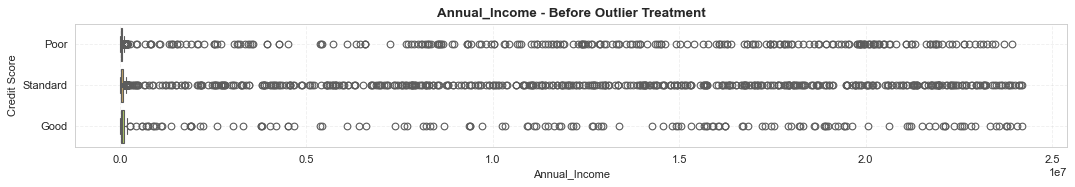

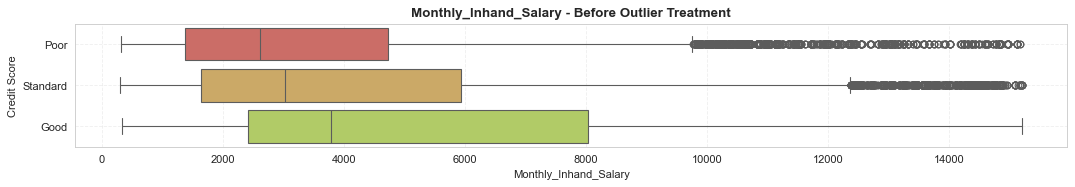

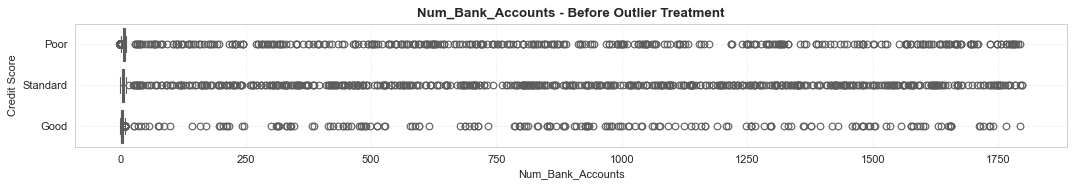

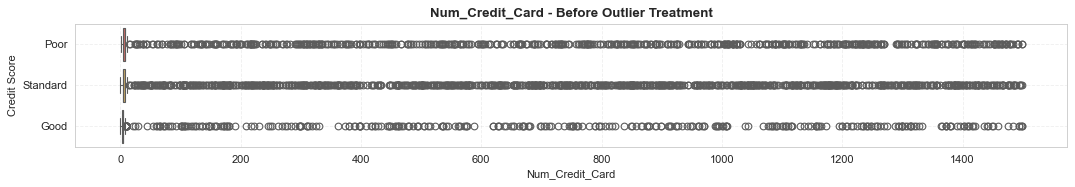

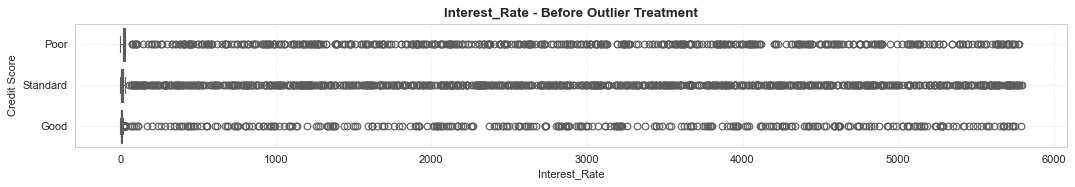

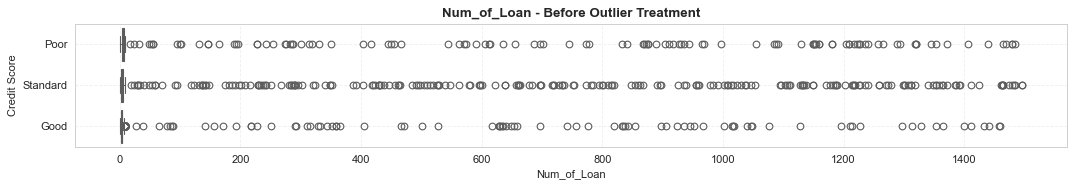

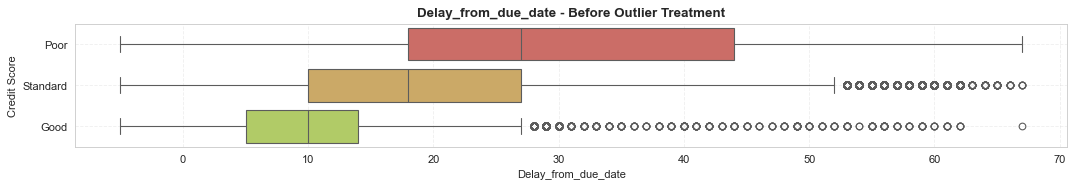

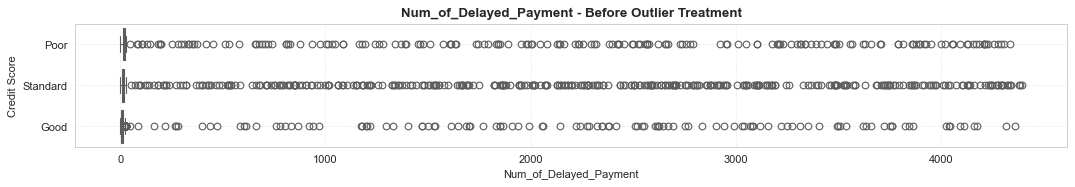

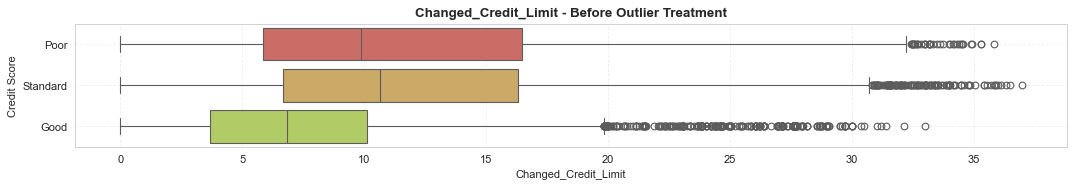

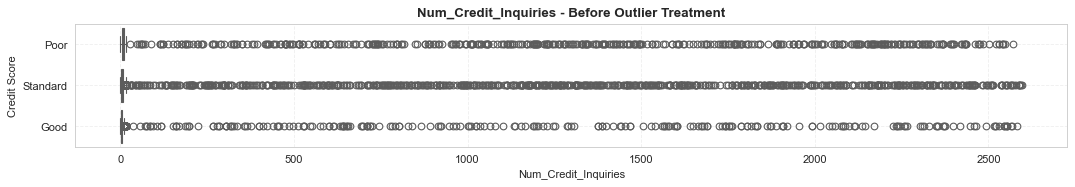

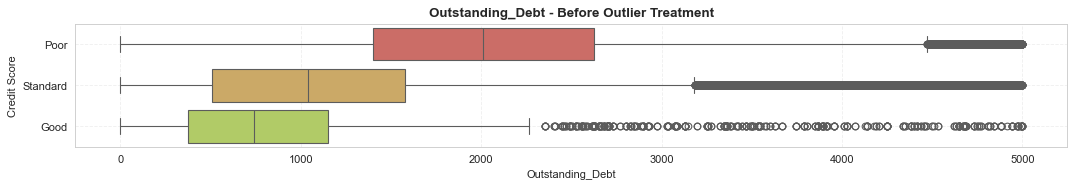

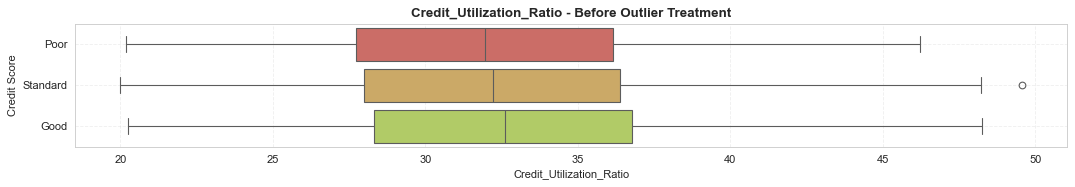

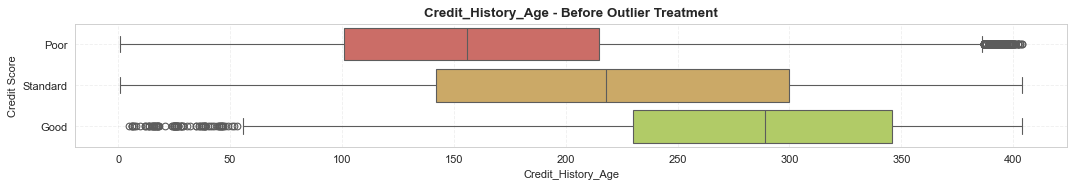

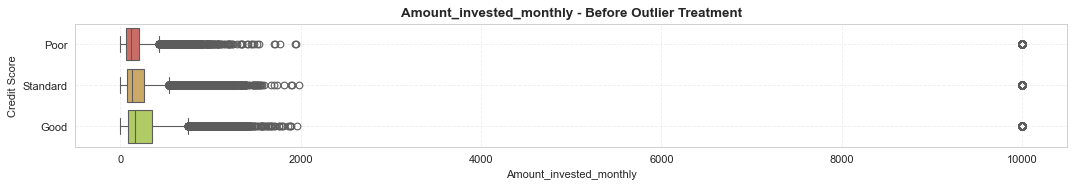

In [318]:
# Boxplots for each numerical feature by Credit Score (BEFORE outlier treatment)
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    # Use dictionary mapping to ensure consistent colors regardless of class ordering
    sns.boxplot(x=df[col], y=df['Credit_Score'], data=df, orient='h', palette=CREDIT_SCORE_COLORS, order=['Poor', 'Standard', 'Good'])
    plt.title(f'{col} - Before Outlier Treatment', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Credit Score')
    plt.grid(alpha=0.3, linestyle='--')
    plt.show()

## 8.4 Outlier Treatment (Capping)

In [319]:
# Function to replace outliers with threshold values (capping) for robust feature scaling
def replace_with_thresholds(data, col):
    lower_limit, upper_limit = outlier_thresholds(data, col)
    data.loc[(data[col] < lower_limit), col] = lower_limit
    data.loc[(data[col] > upper_limit), col] = upper_limit

# Apply outlier capping to all numerical columns
for col in num_cols:
    replace_with_thresholds(df, col)

print("Outlier treatment complete - all outliers capped at IQR boundaries")

Outlier treatment complete - all outliers capped at IQR boundaries


## 8.5 Boxplot Visualization (After Treatment)

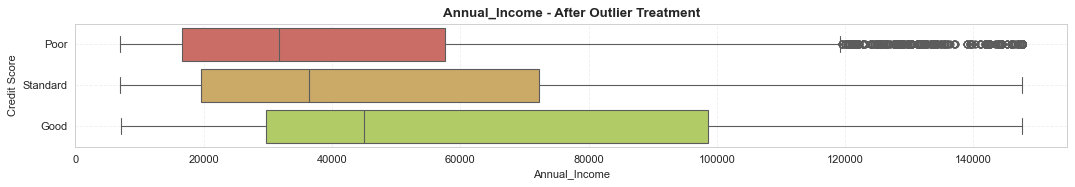

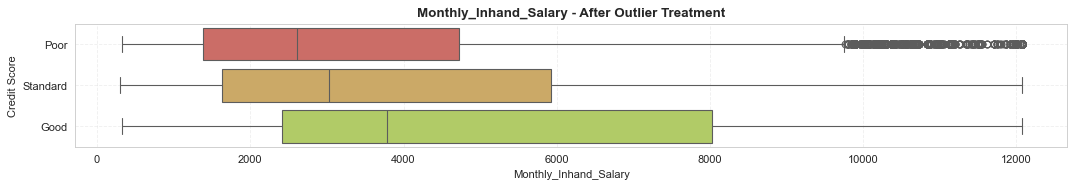

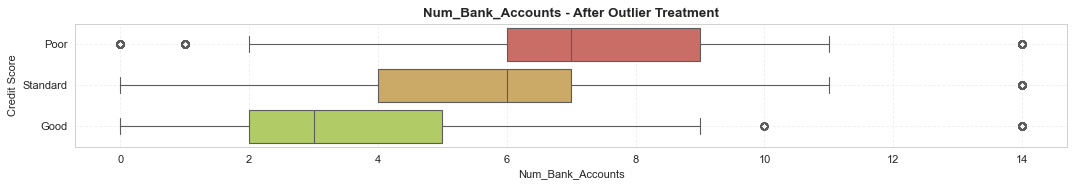

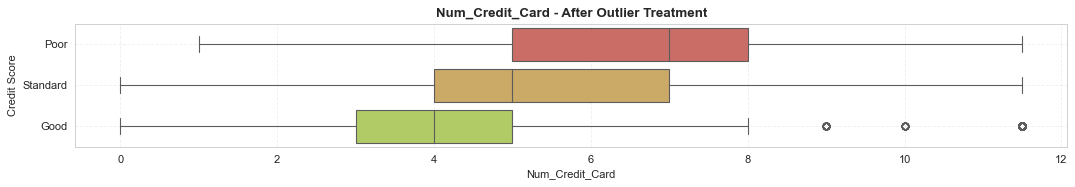

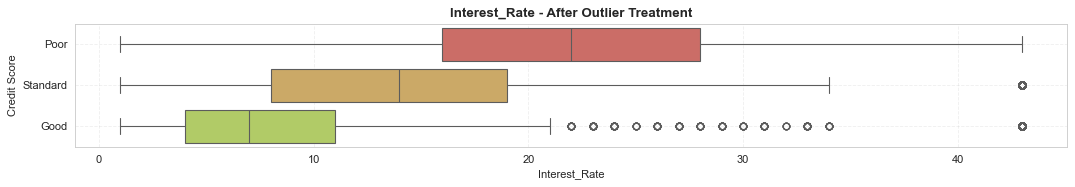

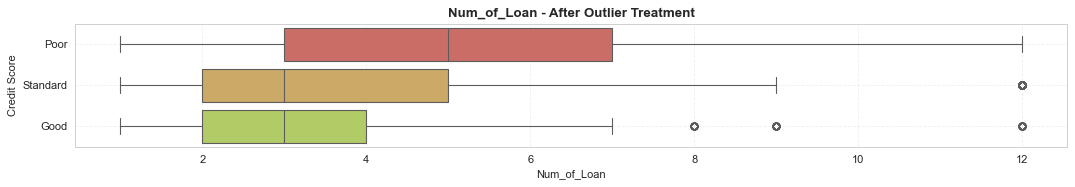

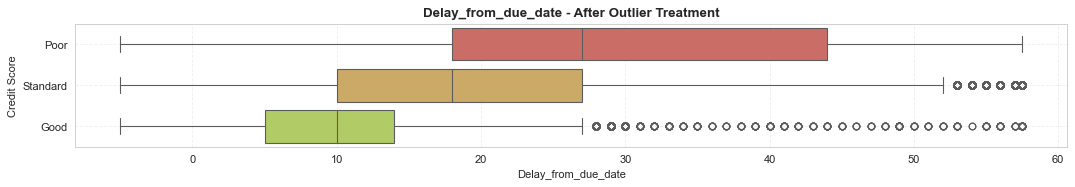

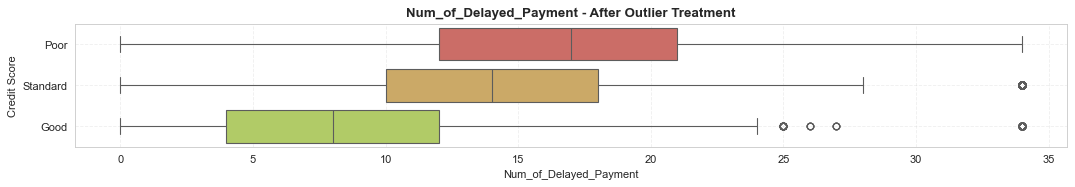

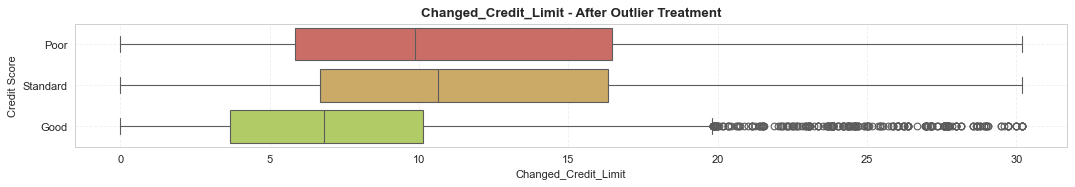

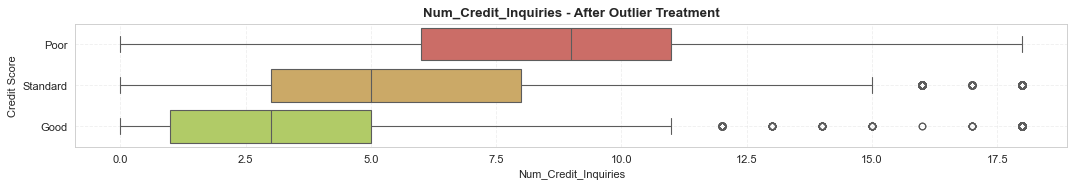

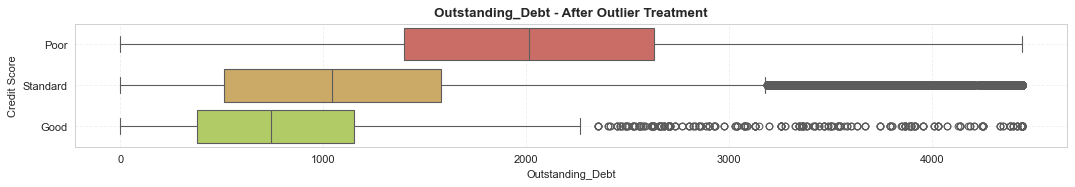

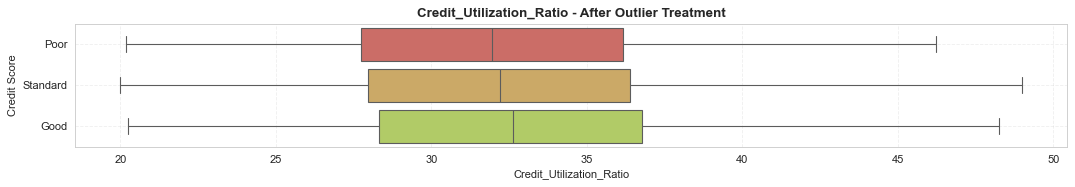

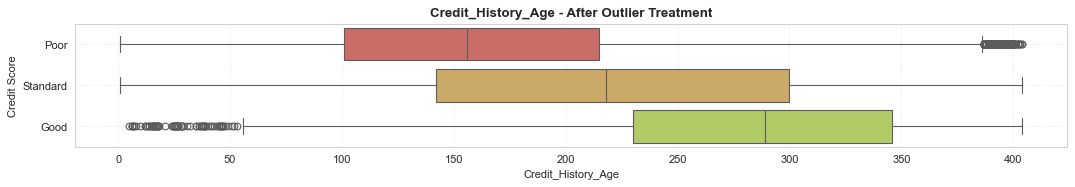

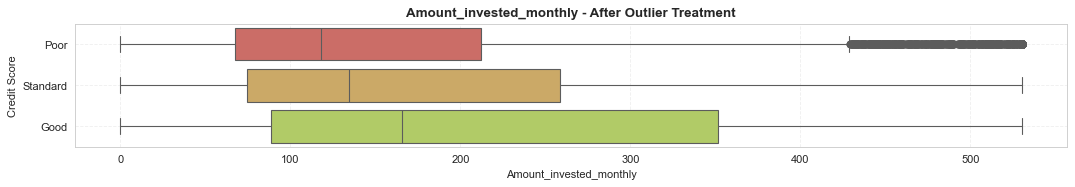

In [320]:
# Boxplots for each numerical feature by Credit Score (AFTER outlier treatment)
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    # Use dictionary mapping to ensure consistent colors regardless of class ordering
    sns.boxplot(x=df[col], y=df['Credit_Score'], data=df, orient='h', palette=CREDIT_SCORE_COLORS, order=['Poor', 'Standard', 'Good'])
    plt.title(f'{col} - After Outlier Treatment', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Credit Score')
    plt.grid(alpha=0.3, linestyle='--')
    plt.show()

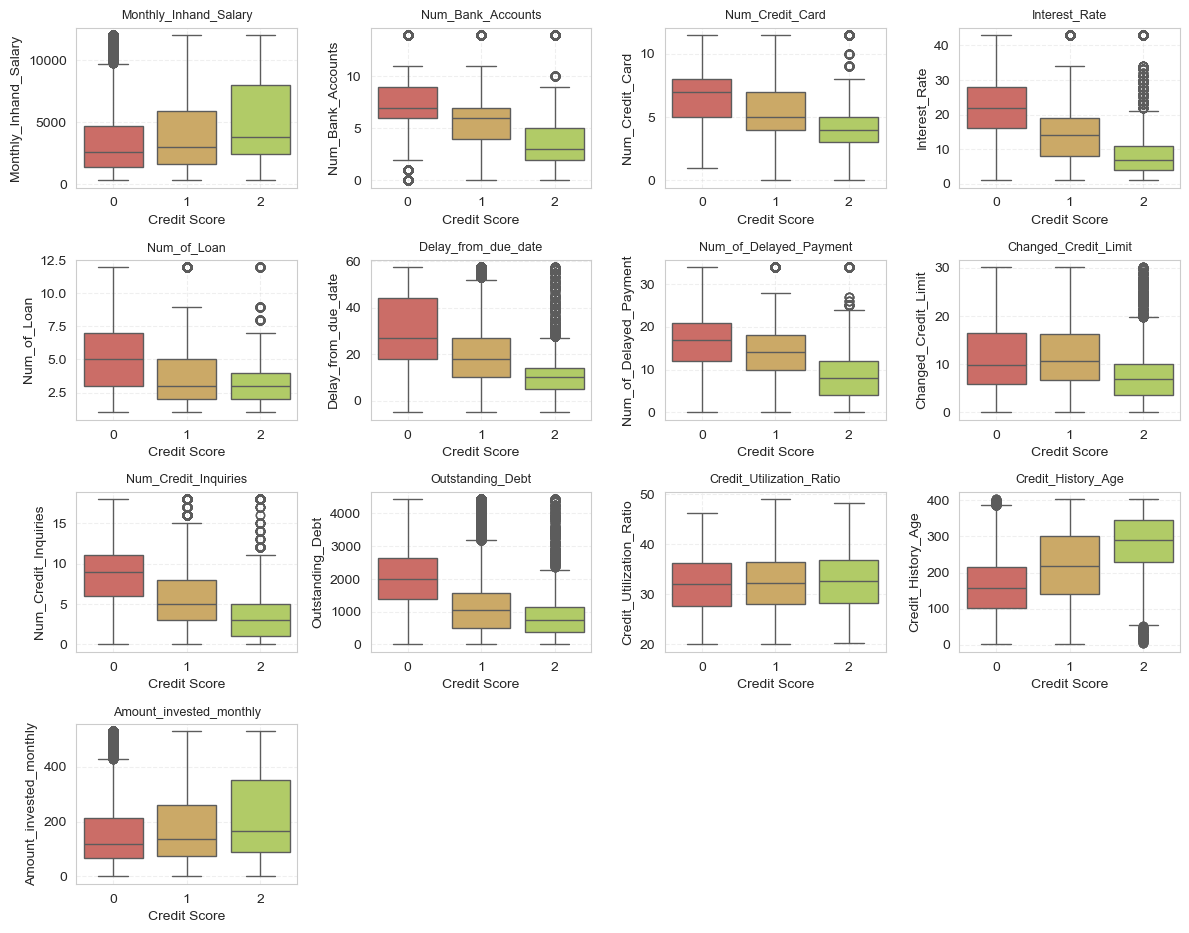

In [321]:
# Multi-panel boxplot visualization with encoded Credit_Score (AFTER outlier treatment)
df_temp = df.copy()
temp_label_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_temp['Credit_Score'] = df_temp['Credit_Score'].map(temp_label_map)
# Select numeric columns (excluding Customer_ID and loan type binary columns)
df_numeric_vis = df_temp.select_dtypes(include=['int', 'float'])
# Remove loan type binary columns
cols_to_drop_vis = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
 ]
df_numeric_vis = df_numeric_vis.drop(cols_to_drop_vis, axis=1)
plt.figure(figsize=(12, 16))
for ax, col in enumerate(df_numeric_vis.columns[2:-1]):
    plt.subplot(7, 4, ax + 1)
    plt.title(col, fontsize=9)
    # Use order parameter to ensure Poor (0), Standard (1), Good (2) ordering
    # For encoded values, use color list in proper order: 0=Poor, 1=Standard, 2=Good
    colors_encoded = [CREDIT_SCORE_COLORS['Poor'], CREDIT_SCORE_COLORS['Standard'], CREDIT_SCORE_COLORS['Good']]
    sns.boxplot(x='Credit_Score', y=col, data=df_numeric_vis, order=[0, 1, 2], palette=colors_encoded)
    plt.xlabel('Credit Score')
    plt.ylabel(col)
    plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 8.6 Distribution Comparison (Before/After)

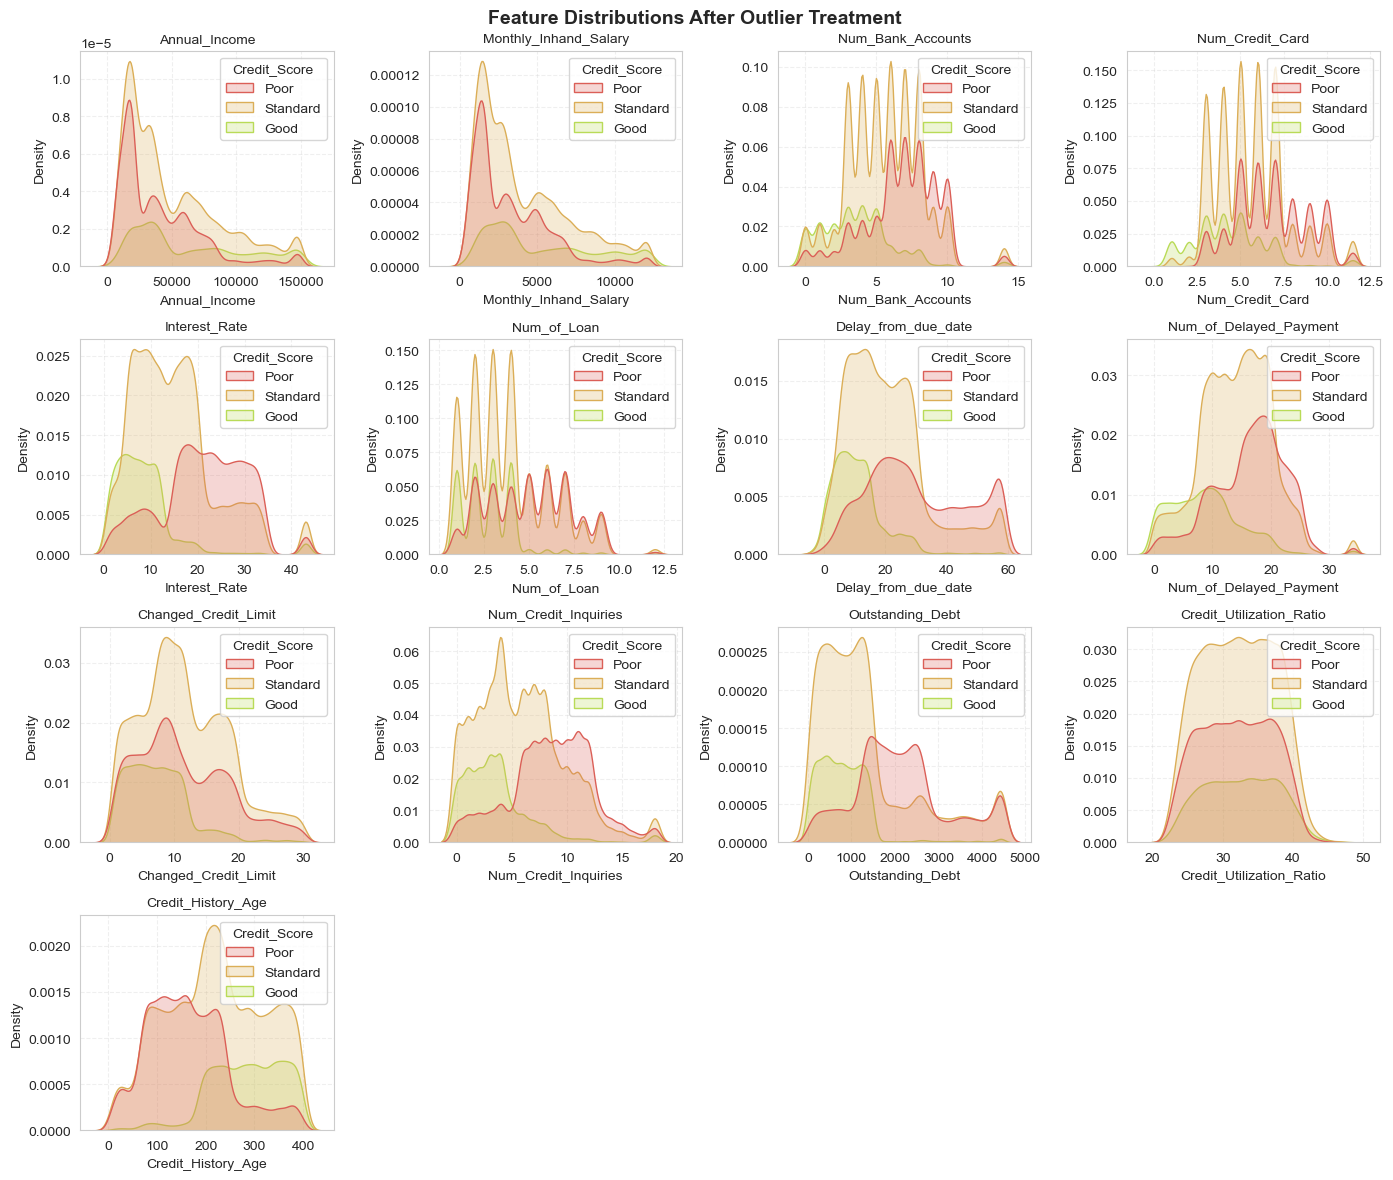

In [322]:
# KDE plots showing distribution after outlier treatment for each numerical feature
plt.figure(figsize=(14, 12))
for ax, col in enumerate(num_cols[:-1]):
    plt.subplot(4, 4, ax + 1)
    plt.title(col, fontsize=10)
    # Use dictionary mapping to ensure consistent colors regardless of class ordering
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'], palette=CREDIT_SCORE_COLORS, hue_order=['Poor', 'Standard', 'Good'])
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(alpha=0.3, linestyle='--')
plt.suptitle('Feature Distributions After Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Encoding

### 9.1 Target Variable Encoding

Encode Credit_Score categories to numerical labels: Poor=0, Standard=1, Good=2.

In [323]:
# Encode Credit_Score: Poor=0, Standard=1, Good=2 for modelling
label_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}
df['Credit_Score'] = df['Credit_Score'].map(label_map)

print("Credit Score encoding:")
print(df['Credit_Score'].value_counts().sort_index())

Credit Score encoding:
Credit_Score
0    27662
1    46546
2    14384
Name: count, dtype: int64


## 9.2 Separate Features and Target

## 9.1b Visualize Categorical Features vs Encoded Target

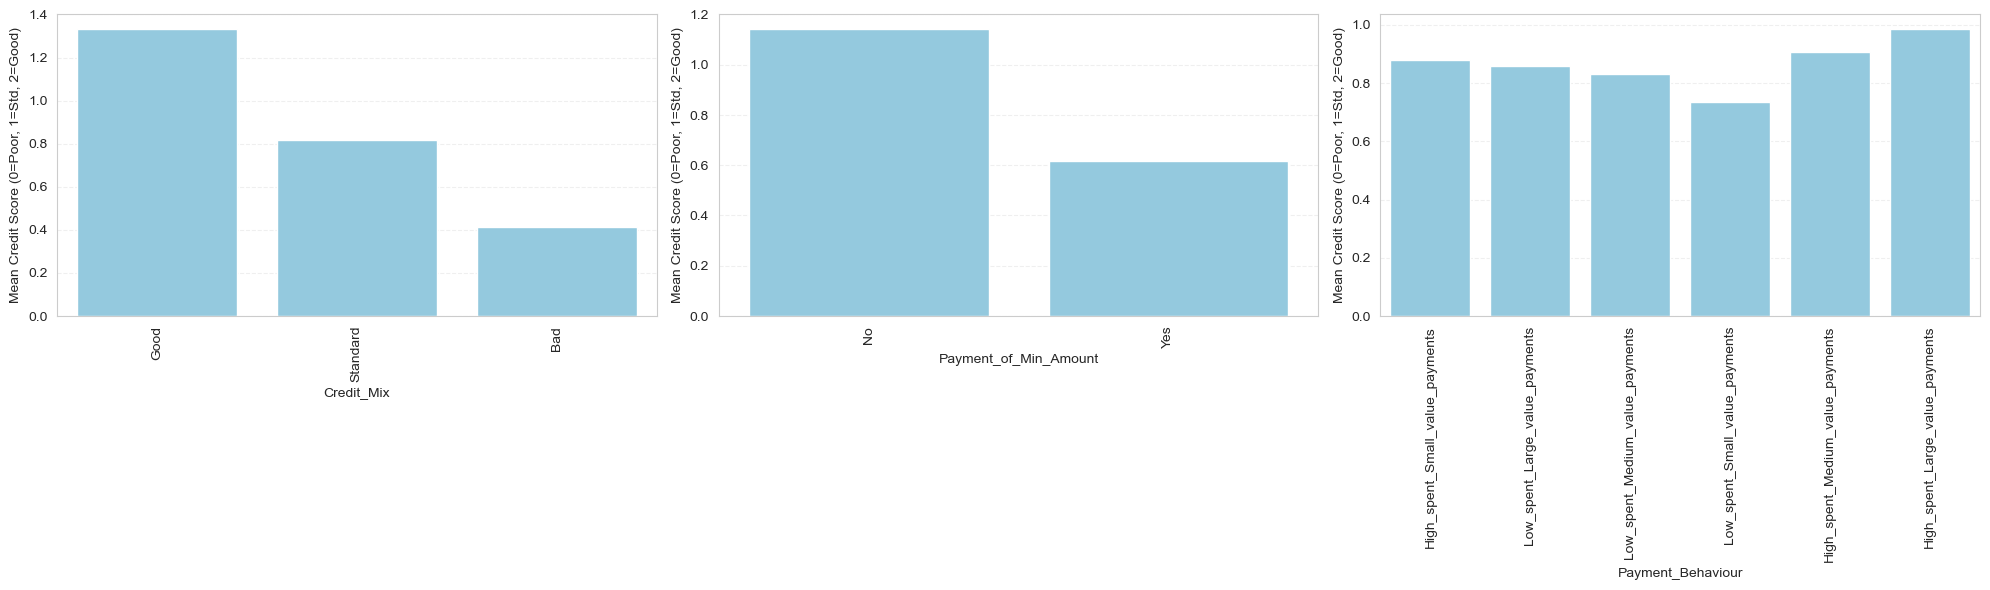

In [325]:
# Visualize relationship between categorical features and Credit Score (now numeric)
cat_cols = df.select_dtypes(include='object').columns.tolist()
if len(cat_cols) > 0:
    plt.figure(figsize=(20, 6))
    for i, col in enumerate(cat_cols, start=1):
        plt.subplot(1, len(cat_cols), i)
        # For barplot with numeric Credit_Score, use default palette (not class-specific)
        g = sns.barplot(x=col, y='Credit_Score', data=df, errorbar=None, color='skyblue')
        g.set_ylabel('Mean Credit Score (0=Poor, 1=Std, 2=Good)')
        g.set_xlabel(col)
        g.set_xticklabels(g.get_xticklabels(), rotation=90)
        g.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns remaining at this stage.")

In [326]:
# Separate features (X) and target (y) for modelling
features = df.drop('Credit_Score', axis=1)
label = df['Credit_Score']

print(f"Features shape: {features.shape}")
print(f"Label shape: {label.shape}")
print(f"\nLabel distribution:")
print(label.value_counts().sort_index())

Features shape: (88592, 26)
Label shape: (88592,)

Label distribution:
Credit_Score
0    27662
1    46546
2    14384
Name: count, dtype: int64


### 9.3 Encode Categorical Features

Apply ordinal encoding for Credit_Mix, binary encoding for Payment_of_Min_Amount, and one-hot encoding for Payment_Behaviour.

In [327]:
# Check remaining categorical columns and their value counts for encoding
cat_col = features.select_dtypes(include='object').columns.tolist()

print(f"Remaining categorical columns: {cat_col}")
for col in cat_col:
    print(f"\n{col} value counts:")
    print(features[col].value_counts())

Remaining categorical columns: ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

Credit_Mix value counts:
Credit_Mix
Standard    40736
Good        24088
Bad         23768
Name: count, dtype: int64

Payment_of_Min_Amount value counts:
Payment_of_Min_Amount
Yes    49515
No     39077
Name: count, dtype: int64

Payment_Behaviour value counts:
Payment_Behaviour
Low_spent_Small_value_payments      25227
High_spent_Medium_value_payments    16993
High_spent_Large_value_payments     13199
Low_spent_Medium_value_payments     12887
High_spent_Small_value_payments     10613
Low_spent_Large_value_payments       9673
Name: count, dtype: int64


In [328]:
# Ordinal encoding for Credit_Mix and binary encoding for Payment_of_Min_Amount
cred_mix = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}

features['Credit_Mix'] = features['Credit_Mix'].map(cred_mix)

# Binary encoding for Payment_of_Min_Amount (No=0, Yes=1)
min_pay = {
    'No': 0,
    'Yes': 1,
}

features['Payment_of_Min_Amount'] = features['Payment_of_Min_Amount'].map(min_pay)

print("Ordinal encoding complete for Credit_Mix and Payment_of_Min_Amount")

Ordinal encoding complete for Credit_Mix and Payment_of_Min_Amount


In [329]:
# One-hot encoding for Payment_Behaviour (drop_first to avoid multicollinearity)
features = pd.get_dummies(features, columns=['Payment_Behaviour'], drop_first=True, dtype=int)

print(f"One-hot encoding complete")
print(f"New features shape: {features.shape}")

One-hot encoding complete
New features shape: (88592, 30)


## 9.4 Data Type Optimization

In [330]:
# Convert float columns that contain only integers to int type
float_cols_with_integers = df.select_dtypes(include='float').apply(
    lambda col: col.apply(lambda x: x.is_integer())).all()
float_cols_to_convert = float_cols_with_integers[float_cols_with_integers].index

features[float_cols_to_convert] = features[float_cols_to_convert].astype(int)

print(f"Converted {len(float_cols_to_convert)} float columns to int")

Converted 2 float columns to int


In [331]:
#  Credit_History_Age to int
features['Credit_History_Age'] = features['Credit_History_Age'].astype(int)


## 9.5 Final Feature Overview

In [332]:
# Display features info
print("Features Information:")
features.info()

print("\nFeatures sample:")
features.head()

Features Information:
<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Customer_ID                                         88592 non-null  int64  
 1   Annual_Income                                       88592 non-null  float64
 2   Monthly_Inhand_Salary                               88592 non-null  float64
 3   Num_Bank_Accounts                                   88592 non-null  int64  
 4   Num_Credit_Card                                     88592 non-null  float64
 5   Interest_Rate                                       88592 non-null  int64  
 6   Num_of_Loan                                         88592 non-null  int64  
 7   Delay_from_due_date                                 88592 non-null  float64
 8   Num_of_Delayed_Payment                              88592 n

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Home Equity Loan,Mortgage Loan,Student Loan,Debt Consolidation Loan,Payday Loan,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,3392,19114.12,1824.843333,3,4.0,3,4,3.0,7.0,11.27,...,1,0,0,0,0,0,1,0,0,0
1,3392,19114.12,1824.843333,3,4.0,3,4,-1.0,6.5,11.27,...,1,0,0,0,0,0,0,1,0,0
2,3392,19114.12,1824.843333,3,4.0,3,4,3.0,7.0,11.27,...,1,0,0,0,0,0,0,0,1,0
3,3392,19114.12,1824.843333,3,4.0,3,4,5.0,4.0,6.27,...,1,0,0,0,0,0,0,0,0,1
4,3392,19114.12,1824.843333,3,4.0,3,4,6.0,6.5,11.27,...,1,0,0,0,0,1,0,0,0,0


## 9.6 Post-Encoding Correlation Matrix

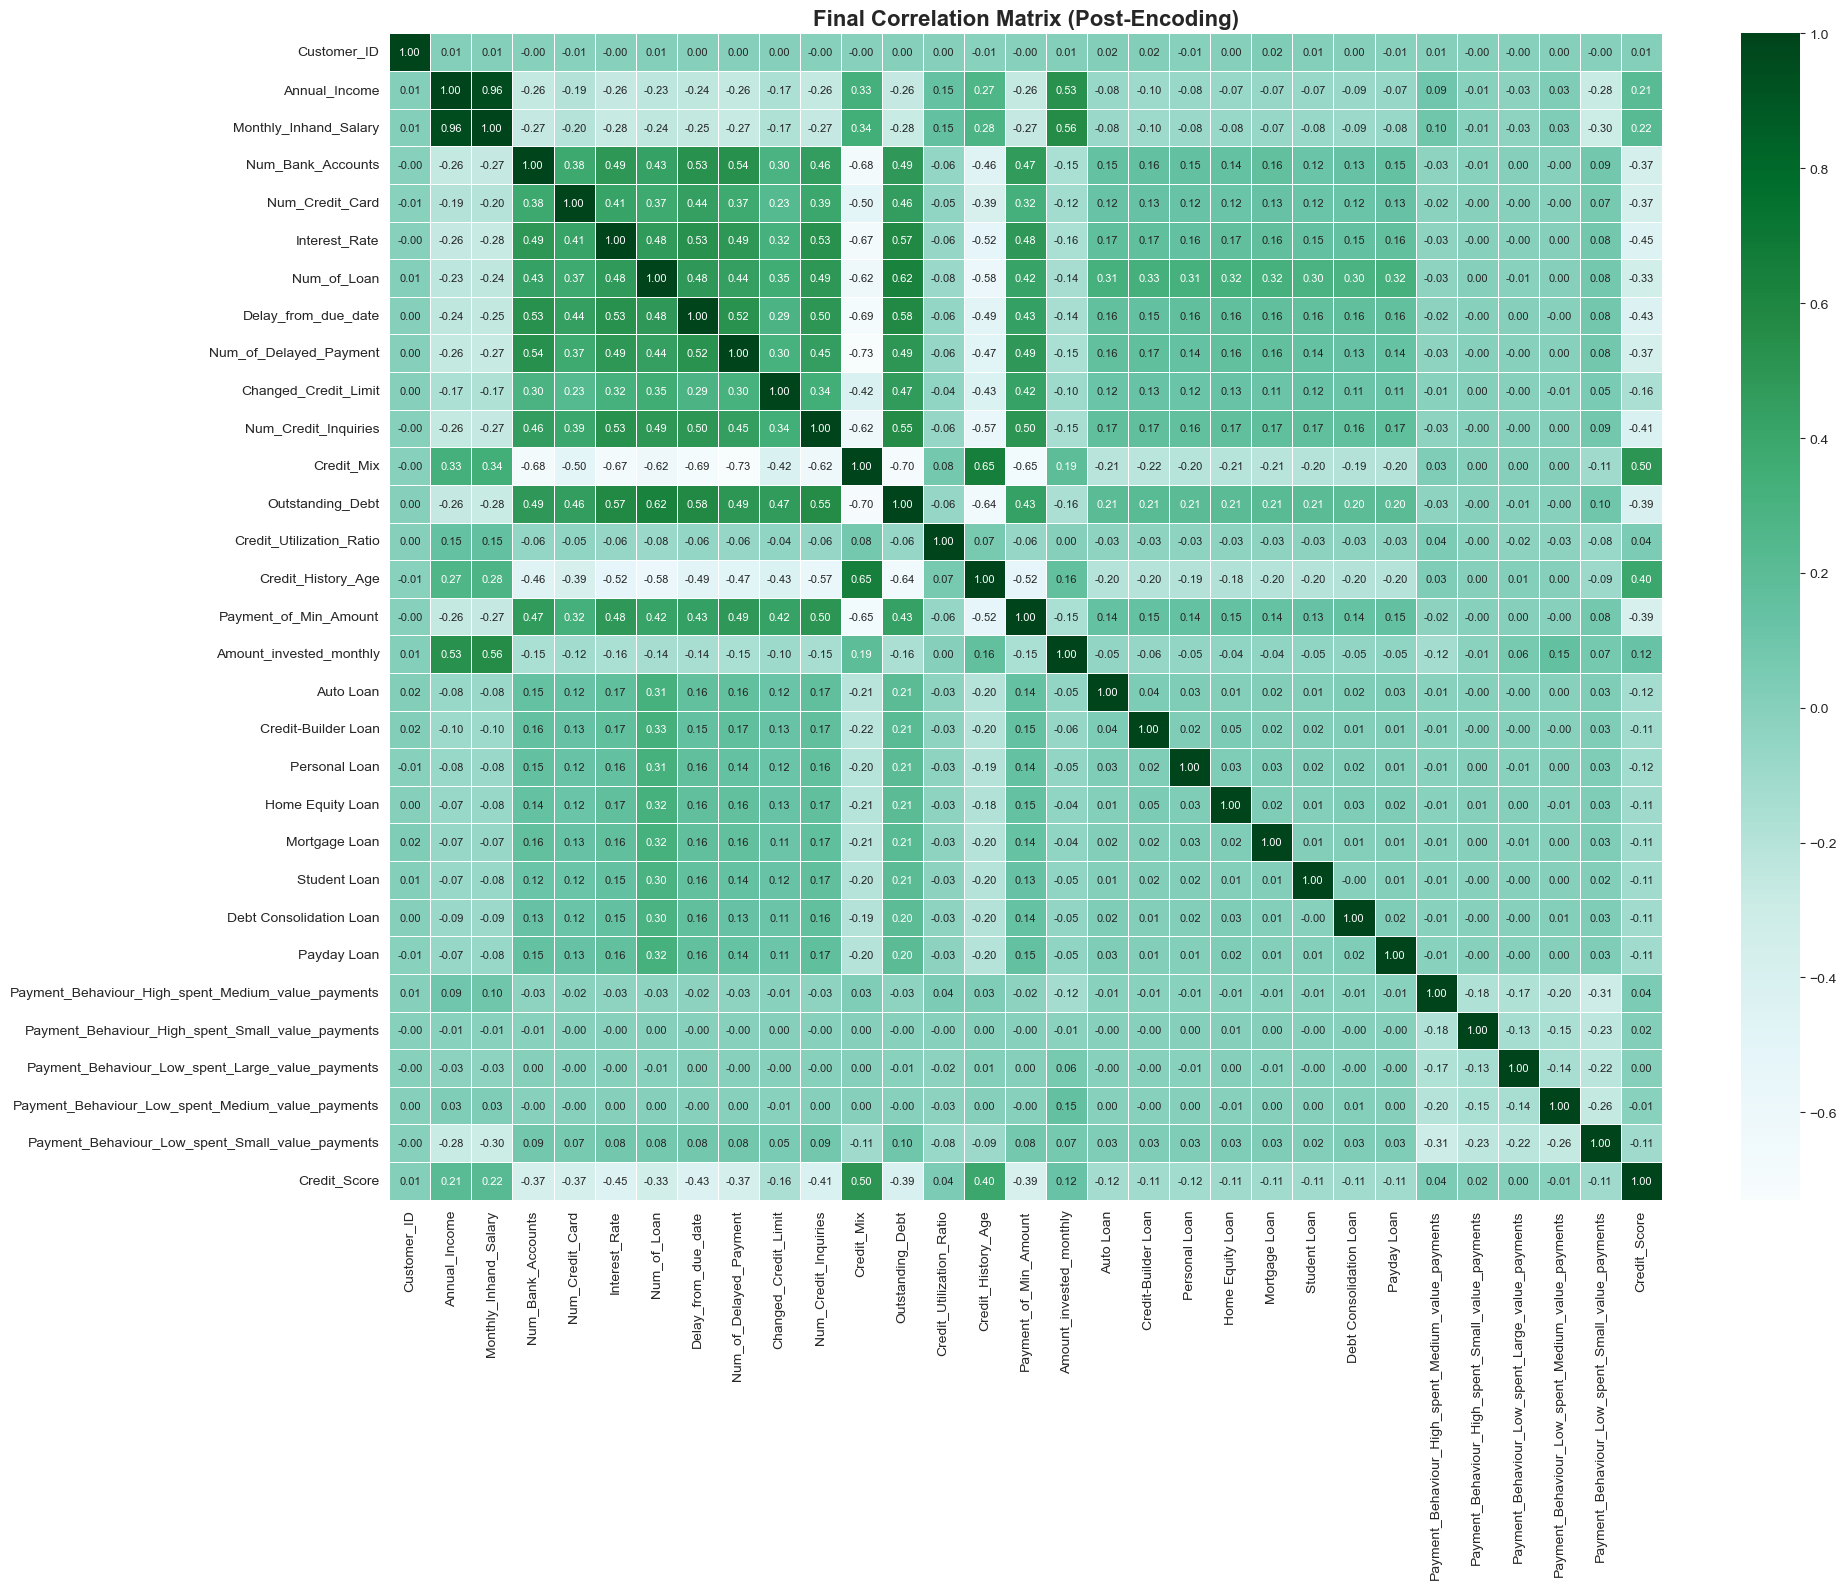

In [333]:
# Create final correlation matrix with all encoded features
final_df = features.copy()
final_df['Credit_Score'] = label

corr_matrix = final_df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5, annot_kws={'size': 8})
plt.title('Final Correlation Matrix (Post-Encoding)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Preprocessing for Modeling

### 10.1 Feature-Target Split Verification

Verify that features and target are properly separated before model training.

In [334]:
# Verify features and target are properly separated
print("="*60)
print("FEATURE-TARGET SPLIT VERIFICATION")
print("="*60)

print(f"\nFeatures (X) shape: {features.shape}")
print(f"Target (y) shape: {label.shape}")

print(f"\nNumber of features: {features.shape[1]}")
print(f"Number of samples: {features.shape[0]}")

print(f"\nFeatures data types:")
print(features.dtypes.value_counts())

print(f"\nTarget distribution:")
print(label.value_counts().sort_index())
print(f"\nTarget distribution (%):")
print(label.value_counts(normalize=True).sort_index() * 100)

FEATURE-TARGET SPLIT VERIFICATION

Features (X) shape: (88592, 30)
Target (y) shape: (88592,)

Number of features: 30
Number of samples: 88592

Features data types:
int64      20
float64    10
Name: count, dtype: int64

Target distribution:
Credit_Score
0    27662
1    46546
2    14384
Name: count, dtype: int64

Target distribution (%):
Credit_Score
0    31.224038
1    52.539733
2    16.236229
Name: proportion, dtype: float64


### 10.2 Train-Test Split (Stratified)

Split data into 80% training and 20% testing with stratification to maintain class balance.

In [335]:
# Split data into training and testing sets (80-20 split with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    label, 
    test_size=0.2, 
    random_state=42, 
    stratify=label
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(features)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(features)*100:.1f}%)")

print(f"\nTraining set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting set class distribution:")
print(y_test.value_counts().sort_index())

TRAIN-TEST SPLIT

Training set size: 70873 samples (80.0%)
Testing set size: 17719 samples (20.0%)

Training set shape: X_train=(70873, 30), y_train=(70873,)
Testing set shape: X_test=(17719, 30), y_test=(17719,)

Training set class distribution:
Credit_Score
0    22129
1    37237
2    11507
Name: count, dtype: int64

Testing set class distribution:
Credit_Score
0    5533
1    9309
2    2877
Name: count, dtype: int64


### 10.3 Feature Selection and Scaling

Apply feature selection to reduce dimensionality and scale features for optimal model performance. Two scaling strategies are used: RobustScaler (most models) and MinMaxScaler (MultinomialNB).

In [336]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Apply feature selection to reduce noise
print("Applying Feature Selection...")

original_feature_count = X_train.shape[1]

# Use mutual information for feature selection
selector = SelectKBest(mutual_info_classif, k=20)

# Fit and transform both sets
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()

# Convert back to DataFrames
X_train = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

print(f"Reduced from {original_feature_count} to {X_train.shape[1]} features")
print(f"Selected features: {selected_features}")

Applying Feature Selection...
Reduced from 30 to 20 features
Selected features: ['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Auto Loan', 'Personal Loan', 'Home Equity Loan', 'Payday Loan']
Reduced from 30 to 20 features
Selected features: ['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Auto Loan', 'Personal Loan', 'Home Equity Loan', 'Payday Loan']


In [337]:
# Dual scaling strategy for different algorithms

# RobustScaler (outlier-robust, for most models)
robust_scaler = RobustScaler()
X_train_scaled = robust_scaler.fit_transform(X_train.copy())
X_test_scaled = robust_scaler.transform(X_test.copy())

# MinMaxScaler (non-negative features for MultinomialNB)
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train.copy())
X_test_minmax = minmax_scaler.transform(X_test.copy())

print(f"RobustScaler applied: {X_train_scaled.shape}")
print(f"MinMaxScaler applied: {X_train_minmax.shape}")

RobustScaler applied: (70873, 20)
MinMaxScaler applied: (70873, 20)


## 11. Modeling & Evaluation

### 11.1 Import Modeling Libraries

Import libraries for model training, evaluation, and visualization.

In [338]:
# Classification algorithms
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation and tuning
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

import time
sns.set_style('whitegrid')

### 11.2 Training and Evaluation Function

This function automates the complete training and evaluation pipeline for any classifier:

**Process:**
1. **Hyperparameter Tuning**: Performs GridSearchCV with 5-fold cross-validation to find optimal parameters
2. **Model Training**: Trains the model with best parameters on the full training set
3. **Predictions**: Generates predictions on both training and test sets
4. **Metrics Calculation**: Computes accuracy, precision, recall, F1 score for both sets
5. **Overfitting Detection**: Calculates performance gap between training and test sets
6. **Visualizations**: Creates confusion matrix, ROC curves (one-vs-rest), and learning curves

**Key Features:**
- Automatic tracking of training time
- Multi-class ROC curve visualization with AUC scores
- Learning curve analysis to detect overfitting/underfitting
- Comprehensive classification report with per-class metrics
- Consistent color scheme across all visualizations

In [339]:
def train_and_evaluate(model, param_grid, name, X_train_data, y_train_data, X_test_data):
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")
    
    grid_search_start_time = time.time()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_data, y_train_data)
    total_grid_search_time = time.time() - grid_search_start_time
    
    best_model_training_time = grid_search.cv_results_['mean_fit_time'][grid_search.best_index_]
    best_model = grid_search.best_estimator_
    
    # Predictions for training and test sets
    y_train_pred = best_model.predict(X_train_data)
    y_pred = best_model.predict(X_test_data)
    y_pred_proba = best_model.predict_proba(X_test_data)
    
    # Training metrics
    train_accuracy = accuracy_score(y_train_data, y_train_pred)
    train_precision = precision_score(y_train_data, y_train_pred, average='weighted', zero_division=0)
    train_recall = recall_score(y_train_data, y_train_pred, average='weighted', zero_division=0)
    train_f1 = f1_score(y_train_data, y_train_pred, average='weighted', zero_division=0)
    
    # Test metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    accuracy_gap = train_accuracy - accuracy
    precision_gap = train_precision - precision
    recall_gap = train_recall - recall
    f1_gap = train_f1 - f1
    max_gap = max(accuracy_gap, precision_gap, recall_gap, f1_gap)
    
    if max_gap > 0.1:
        overfitting_status = "Overfitting"
    else:
        overfitting_status = "No overfitting"
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Training Time: {best_model_training_time:.2f}s")
    print(f"Training Accuracy: {train_accuracy:.4f} | Test Accuracy: {accuracy:.4f} | Gap: {accuracy_gap:.4f}")
    print(f"Training F1:       {train_f1:.4f} | Test F1:       {f1:.4f} | Gap: {f1_gap:.4f}")
    print(f"Overfitting Status: {overfitting_status}")
    
    print("CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=['Poor', 'Standard', 'Good']))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{name} - Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=['Poor', 'Standard', 'Good'], 
                yticklabels=['Poor', 'Standard', 'Good'])
    axes[0].set_title('Confusion Matrix', fontweight='bold')
    axes[0].set_xlabel('Predicted', fontweight='bold')
    axes[0].set_ylabel('Actual', fontweight='bold')
    
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']
    class_names = ['Poor', 'Standard', 'Good']
    
    for i, color, class_name in zip(range(3), colors, class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')
    
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1].set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)
    axes[1].grid(alpha=0.3)
    
    train_sizes, train_scores, val_scores = learning_curve(
        best_model, X_train_data, y_train_data, 
        cv=5, scoring='f1_weighted', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    axes[2].plot(train_sizes, train_mean, 'o-', color=PALETTE[0], lw=2, label='Training Score')
    axes[2].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                         alpha=0.2, color=PALETTE[0])
    axes[2].plot(train_sizes, val_mean, 'o-', color=PALETTE[1], lw=2, label='Validation Score')
    axes[2].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                         alpha=0.2, color=PALETTE[1])
    axes[2].set_xlabel('Training Size', fontweight='bold')
    axes[2].set_ylabel('F1 Score', fontweight='bold')
    axes[2].set_title('Learning Curve (Overfitting Check)', fontweight='bold')
    axes[2].legend(loc='lower right', fontsize=10)
    axes[2].grid(alpha=0.3)
    axes[2].text(0.03, 0.05, f"Final Gap: {train_mean[-1] - val_mean[-1]:.3f}",
                 transform=axes[2].transAxes,
                 fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return {
        'Model': name,
        'Best_Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Training_Time': best_model_training_time,
        'Train_Accuracy': train_accuracy,
        'Train_Precision': train_precision,
        'Train_Recall': train_recall,
        'Train_F1': train_f1,
        'Accuracy_Gap': accuracy_gap,
        'Precision_Gap': precision_gap,
        'Recall_Gap': recall_gap,
        'F1_Gap': f1_gap,
        'Overfitting_Status': overfitting_status,
        'Best_Estimator': best_model
    }


### 11.3 Model 1: Gaussian Naive Bayes

**Algorithm Overview:**
Gaussian Naive Bayes assumes features follow a normal distribution and are conditionally independent given the class label. It's a probabilistic classifier based on Bayes' theorem.

**Hyperparameters:**
- `var_smoothing`: Portion of largest variance added to all features for stability (prevents zero probabilities)

**Advantages:**
- Fast training and prediction
- Works well with small datasets
- Handles high-dimensional data efficiently
- Probabilistic predictions

**Limitations:**
- Assumes feature independence (rarely true in practice)
- Assumes Gaussian distribution for numerical features
- May underperform with correlated features


Training: Gaussian Naive Bayes
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Parameters: {'var_smoothing': 1e-09}
Training Time: 0.08s
Training Accuracy: 0.6162 | Test Accuracy: 0.6171 | Gap: -0.0009
Training F1:       0.6179 | Test F1:       0.6193 | Gap: -0.0014
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.63      0.72      0.67      5533
    Standard       0.80      0.49      0.61      9309
        Good       0.42      0.83      0.56      2877

    accuracy                           0.62     17719
   macro avg       0.62      0.68      0.61     17719
weighted avg       0.68      0.62      0.62     17719


Best Parameters: {'var_smoothing': 1e-09}
Training Time: 0.08s
Training Accuracy: 0.6162 | Test Accuracy: 0.6171 | Gap: -0.0009
Training F1:       0.6179 | Test F1:       0.6193 | Gap: -0.0014
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision

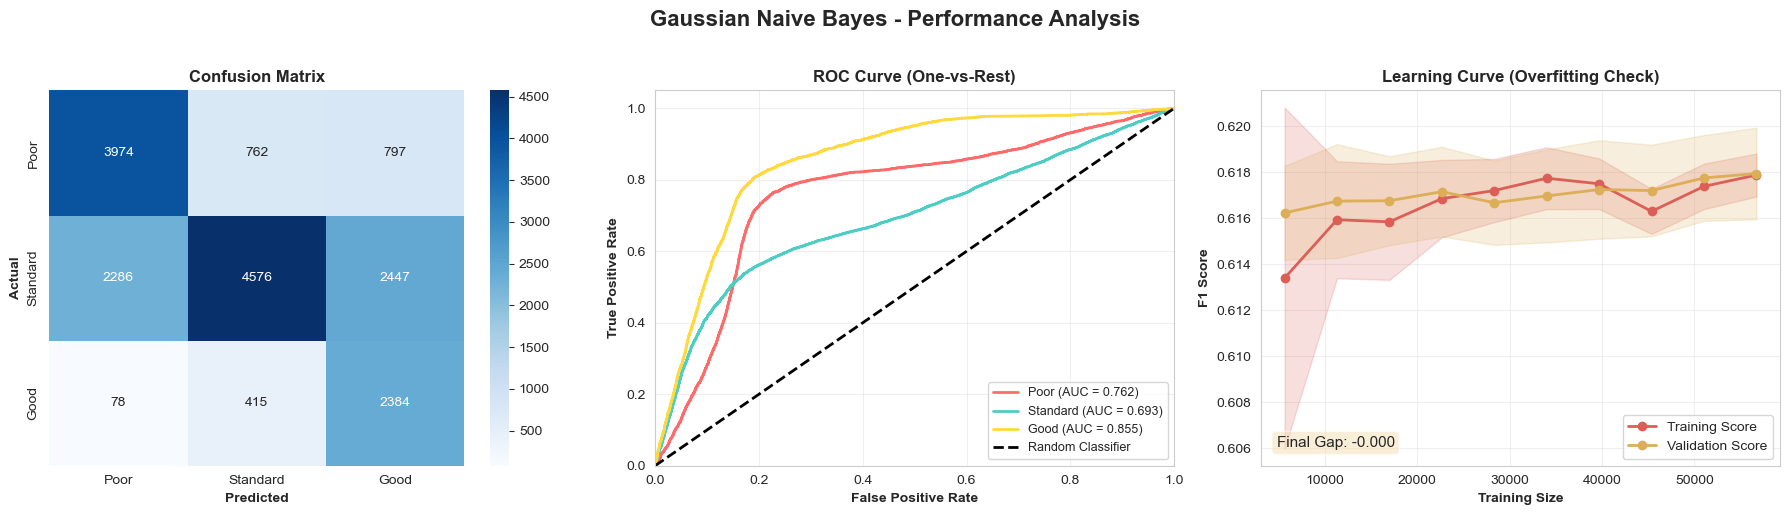

In [340]:
nb_params = {'var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3]}
nb_results = train_and_evaluate(GaussianNB(), nb_params, 'Gaussian Naive Bayes',
                                X_train_scaled, y_train, X_test_scaled)

### 11.4 Model 2: Multinomial Naive Bayes

**Algorithm Overview:**
Multinomial Naive Bayes is typically used for discrete counts (e.g., word counts for text classification). Requires non-negative features, hence MinMaxScaler is used.

**Hyperparameters:**
- `alpha`: Additive (Laplace/Lidstone) smoothing parameter to handle zero probabilities

**Advantages:**
- Efficient for discrete/count data
- Handles sparse features well
- Simple and interpretable

**Note:**
This variant requires non-negative features, which is why we use MinMaxScaler instead of RobustScaler for this model.


Training: Multinomial Naive Bayes
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters: {'alpha': 0.5}
Training Time: 0.02s
Training Accuracy: 0.5794 | Test Accuracy: 0.5779 | Gap: 0.0016
Training F1:       0.5623 | Test F1:       0.5596 | Gap: 0.0027
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.59      0.41      0.48      5533
    Standard       0.59      0.77      0.67      9309
        Good       0.49      0.30      0.37      2877

    accuracy                           0.58     17719
   macro avg       0.55      0.49      0.50     17719
weighted avg       0.57      0.58      0.56     17719


Best Parameters: {'alpha': 0.5}
Training Time: 0.02s
Training Accuracy: 0.5794 | Test Accuracy: 0.5779 | Gap: 0.0016
Training F1:       0.5623 | Test F1:       0.5596 | Gap: 0.0027
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score 

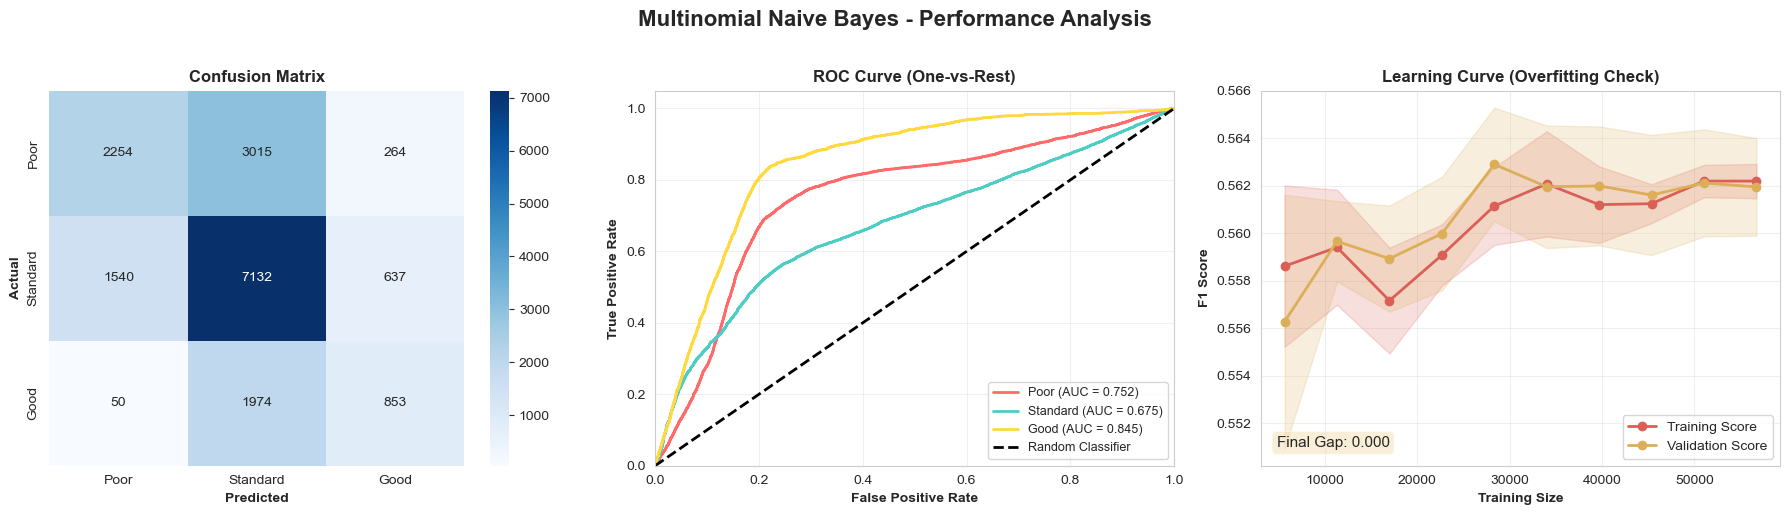

In [341]:
mnb_params = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]} 
mnb_results = train_and_evaluate(MultinomialNB(), mnb_params, 'Multinomial Naive Bayes',
                                 X_train_minmax, y_train, X_test_minmax)

### 11.5 Model 3: Softmax Regression

**Algorithm Overview:**
Softmax Regression models the probability of class membership using the softmax function. It's a linear model that learns decision boundaries.

**Hyperparameters:**
- `C`: Inverse of regularization strength (smaller values = stronger regularization)
- `max_iter`: Maximum iterations for solver convergence
- `class_weight='balanced'`: Automatically adjusts weights inversely proportional to class frequencies
- `multi_class='multinomial'`: Uses softmax function for multi-class classification

**Advantages:**
- Interpretable coefficients
- Probabilistic outputs
- Efficient with large datasets
- Built-in regularization to prevent overfitting

**Limitations:**
- Assumes linear decision boundaries
- Sensitive to feature scaling (handled by RobustScaler)


Training: Logistic Regression (Softmax)
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters: {'C': 0.01}
Training Time: 0.29s
Training Accuracy: 0.6545 | Test Accuracy: 0.6540 | Gap: 0.0005
Training F1:       0.6578 | Test F1:       0.6576 | Gap: 0.0003
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.62      0.69      0.65      5533
    Standard       0.80      0.58      0.67      9309
        Good       0.49      0.82      0.61      2877

    accuracy                           0.65     17719
   macro avg       0.64      0.70      0.65     17719
weighted avg       0.69      0.65      0.66     17719


Best Parameters: {'C': 0.01}
Training Time: 0.29s
Training Accuracy: 0.6545 | Test Accuracy: 0.6540 | Gap: 0.0005
Training F1:       0.6578 | Test F1:       0.6576 | Gap: 0.0003
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score 

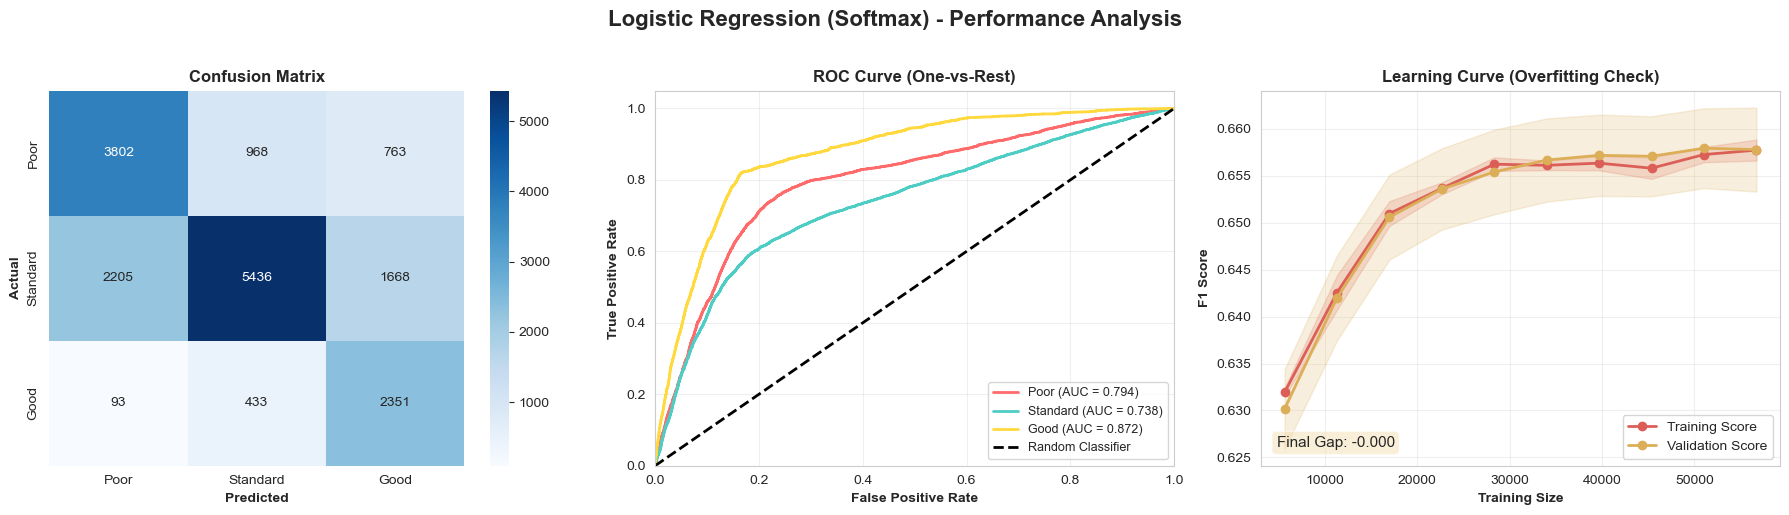

In [342]:
lr_params = {
    'C': [0.001, 0.01, 0.05, 0.1, 1.0], 
}
lr_results = train_and_evaluate(LogisticRegression(max_iter=1000, class_weight='balanced', multi_class='multinomial', penalty='l2'), lr_params, 'Logistic Regression (Softmax)',
                                X_train_scaled, y_train, X_test_scaled)

### 11.6 Model 4: Decision Tree

**Algorithm Overview:**
Decision Trees learn decision rules from features by recursively splitting the data to maximize information gain or minimize impurity (Gini or Entropy).

**Hyperparameters:**
- `max_depth`: Maximum depth of the tree (controls complexity)
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required at leaf nodes
- `criterion`: Function to measure split quality ('gini' or 'entropy')
- `class_weight='balanced'`: Handles class imbalance

**Advantages:**
- Non-linear decision boundaries
- Feature importance scores
- No feature scaling required
- Interpretable (can visualize tree)
- Handles categorical and numerical data

**Limitations:**
- Prone to overfitting without pruning
- High variance (small data changes → different trees)
- Biased toward dominant classes without balancing


Training: Decision Tree
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 20}
Training Time: 0.85s
Training Accuracy: 0.8172 | Test Accuracy: 0.7357 | Gap: 0.0815
Training F1:       0.8175 | Test F1:       0.7365 | Gap: 0.0810
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.72      0.82      0.76      5533
    Standard       0.83      0.66      0.74      9309
        Good       0.59      0.82      0.69      2877

    accuracy                           0.74     17719
   macro avg       0.71      0.77      0.73     17719
weighted avg       0.76      0.74      0.74     17719


Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 20}
Training Time: 0.85s
Training Accuracy: 0.8172 | Test Accuracy: 0.7357 | Gap: 0.0815
Training F1:      

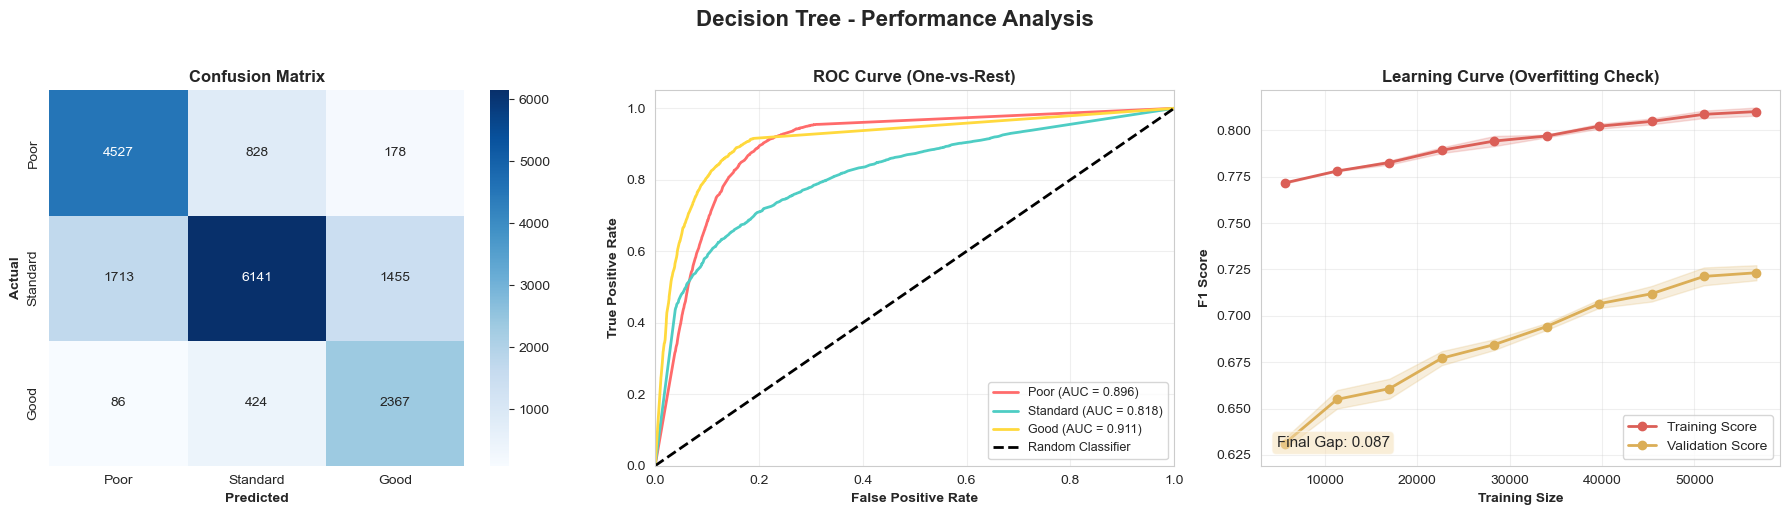

In [343]:
dt_params = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [20, 50],
    'min_samples_leaf': [10, 20],
    'criterion': ['gini', 'entropy']
}
dt_results = train_and_evaluate(DecisionTreeClassifier(random_state=42, class_weight='balanced'), dt_params, 'Decision Tree',
                                X_train_scaled, y_train, X_test_scaled)

### 11.7 Model 5: Random Forest

**Algorithm Overview:**
Random Forest is an ensemble of Decision Trees trained on random subsets of data and features. Final prediction is made by majority voting (classification) or averaging (regression).

**Hyperparameters:**
- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of each tree
- `min_samples_split`: Minimum samples to split a node
- `min_samples_leaf`: Minimum samples at leaf nodes
- `max_features`: Number of features to consider for best split ('sqrt' or None)
- `class_weight='balanced_subsample'`: Balances classes for each bootstrap sample

**Advantages:**
- Reduces overfitting compared to single Decision Tree
- Robust to outliers and noise
- Provides feature importance
- Handles non-linear relationships well
- Less sensitive to hyperparameters

**Limitations:**
- More complex and slower than single trees
- Less interpretable than single Decision Trees
- Can be memory-intensive with many trees


Training: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'max_depth': 25, 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 200}
Training Time: 26.22s
Training Accuracy: 0.8577 | Test Accuracy: 0.7919 | Gap: 0.0658
Training F1:       0.8578 | Test F1:       0.7928 | Gap: 0.0649
Overfitting Status: No overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.77      0.86      0.81      5533
    Standard       0.87      0.73      0.80      9309
        Good       0.66      0.84      0.74      2877

    accuracy                           0.79     17719
   macro avg       0.77      0.81      0.78     17719
weighted avg       0.81      0.79      0.79     17719


Best Parameters: {'max_depth': 25, 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 200}
Training Time: 26.22s
Training Accuracy: 0.8577 | Test Accuracy: 0.7919 | Gap: 0.0658
Training F1:       0.8578 | 

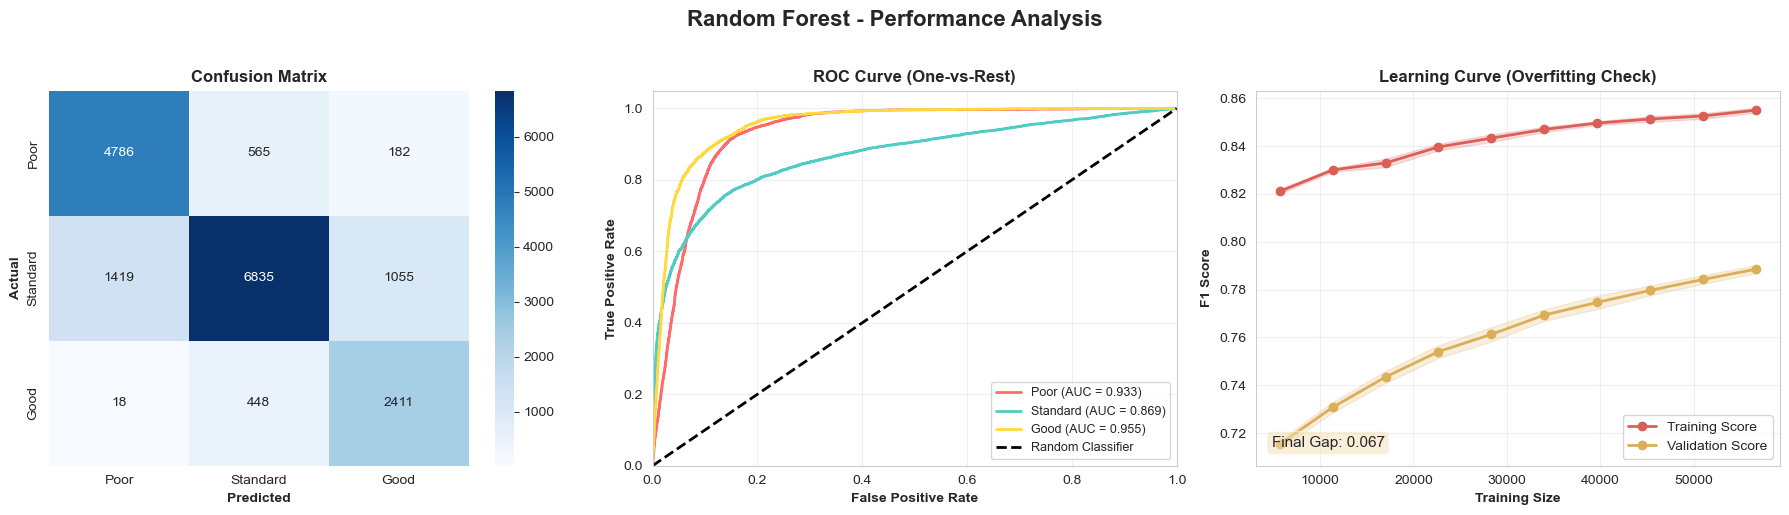

In [344]:
rf_params = {
    'n_estimators': [150, 200],
    'max_depth': [20, 25],
    'min_samples_split': [12, 15, 18],
    'min_samples_leaf': [4, 5, 6],
}
rf_results = train_and_evaluate(RandomForestClassifier(random_state=42, class_weight='balanced_subsample'), rf_params, 'Random Forest',
                                X_train_scaled, y_train, X_test_scaled)

### 11.8 Feature Importance Analysis

After training the Random Forest model, we analyze feature importance to understand which features contribute most to predictions. This helps identify:
- Most influential features for credit score prediction
- Potential for dimensionality reduction
- Features that could be removed without significant performance loss

Feature importance is calculated based on how much each feature decreases impurity across all trees in the forest.

In [345]:
# ===== FEATURE IMPORTANCE ANALYSIS =====
best_rf_model = rf_results['Best_Estimator']
feature_importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# Create DataFrame for better visualization
importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display top 20 features
print("\n📊 Top 20 Most Important Features:")
print(importance_rf.head(20).to_string(index=False))


📊 Top 20 Most Important Features:
                Feature  Importance
             Credit_Mix    0.149874
       Outstanding_Debt    0.145553
          Interest_Rate    0.110459
     Credit_History_Age    0.069158
    Delay_from_due_date    0.068190
   Num_Credit_Inquiries    0.058817
   Changed_Credit_Limit    0.055453
  Monthly_Inhand_Salary    0.043210
            Customer_ID    0.042626
          Annual_Income    0.041527
  Payment_of_Min_Amount    0.039218
        Num_Credit_Card    0.034537
 Num_of_Delayed_Payment    0.032831
      Num_Bank_Accounts    0.032812
Amount_invested_monthly    0.027515
            Num_of_Loan    0.025971
            Payday Loan    0.005698
              Auto Loan    0.005546
          Personal Loan    0.005519
       Home Equity Loan    0.005488


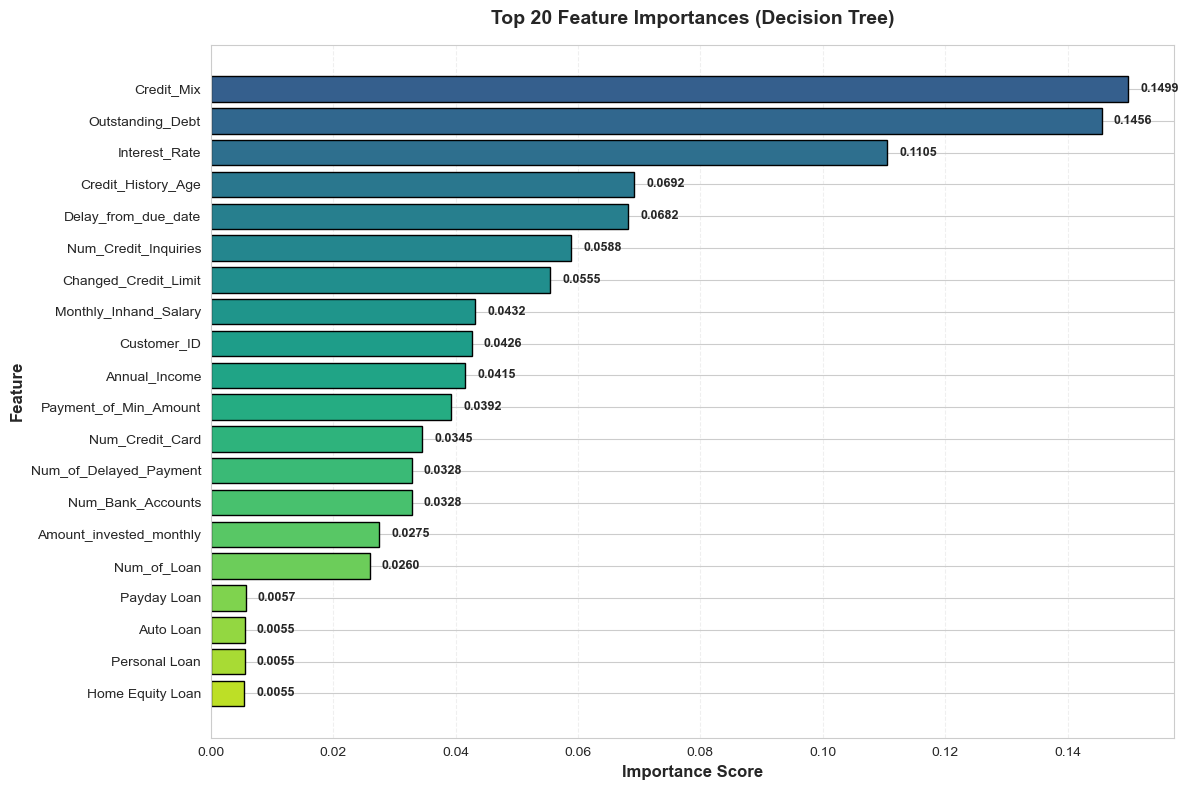

In [346]:
# ===== FEATURE IMPORTANCE BAR PLOT =====
plt.figure(figsize=(12, 8))
top_n = 20  # Show top 20 features
top_features = importance_rf.head(top_n)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
bars = plt.barh(top_features['Feature'], top_features['Importance'], 
                color=colors, edgecolor='black', linewidth=1)

plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Feature Importances (Decision Tree)', 
          fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, value in zip(bars, top_features['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{value:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

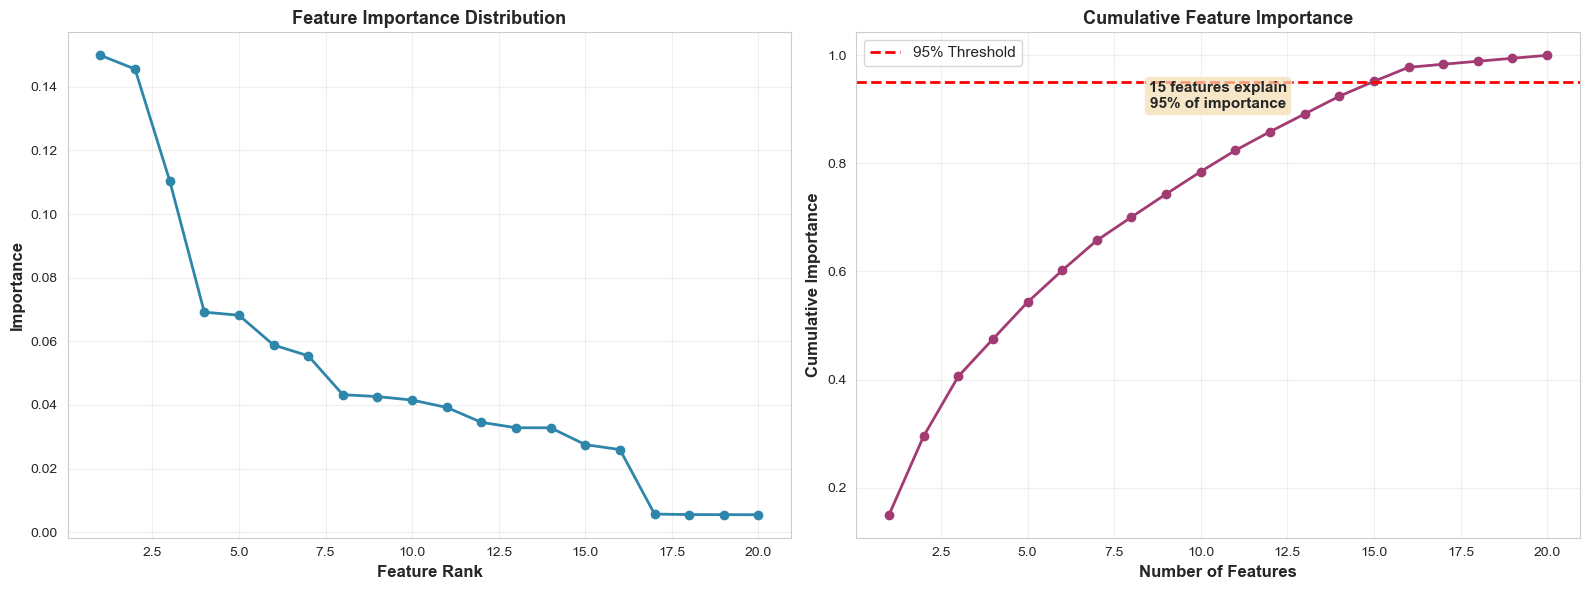


💡 Insight: 15 features explain 95% of the model's decisions
📊 Total features used: 20
🎯 Feature reduction potential: 5 features could be removed


In [347]:
# ===== 4. CUMULATIVE IMPORTANCE PLOT =====
importance_rf['Cumulative_Importance'] = importance_rf['Importance'].cumsum()

# Reset index to ensure proper counting
importance_rf_reset = importance_rf.reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Individual importance
ax1.plot(range(1, len(importance_rf_reset) + 1), importance_rf_reset['Importance'], 
         'o-', color='#2E86AB', linewidth=2, markersize=6)
ax1.set_xlabel('Feature Rank', fontsize=12, fontweight='bold')
ax1.set_ylabel('Importance', fontsize=12, fontweight='bold')
ax1.set_title('Feature Importance Distribution', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

# Right: Cumulative importance
ax2.plot(range(1, len(importance_rf_reset) + 1), importance_rf_reset['Cumulative_Importance'], 
         'o-', color='#A23B72', linewidth=2, markersize=6)
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
ax2.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Find how many features explain 95% of importance
features_for_95 = (importance_rf_reset['Cumulative_Importance'] >= 0.95).idxmax() + 1

ax2.text(0.5, 0.85, f'{features_for_95} features explain\n95% of importance',
         transform=ax2.transAxes, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         ha='center')

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: {features_for_95} features explain 95% of the model's decisions")
print(f"📊 Total features used: {len(feature_names)}")
print(f"🎯 Feature reduction potential: {len(feature_names) - features_for_95} features could be removed")

### 11.9 Model Comparison

Compare all trained models across key metrics to identify the best performer.

In [348]:
results_df = pd.DataFrame([
    {
        'Model': nb_results['Model'],
        'Accuracy': nb_results['Accuracy'],
        'Precision': nb_results['Precision'],
        'Recall': nb_results['Recall'],
        'F1_Score': nb_results['F1_Score'],
        'Training_Time': nb_results['Training_Time'],
        'Train_Accuracy': nb_results['Train_Accuracy'],
        'Train_F1': nb_results['Train_F1'],
        'Accuracy_Gap': nb_results['Accuracy_Gap'],
        'F1_Gap': nb_results['F1_Gap'],
        'Overfitting_Status': nb_results['Overfitting_Status']
    },
    {
        'Model': mnb_results['Model'],
        'Accuracy': mnb_results['Accuracy'],
        'Precision': mnb_results['Precision'],
        'Recall': mnb_results['Recall'],
        'F1_Score': mnb_results['F1_Score'],
        'Training_Time': mnb_results['Training_Time'],
        'Train_Accuracy': mnb_results['Train_Accuracy'],
        'Train_F1': mnb_results['Train_F1'],
        'Accuracy_Gap': mnb_results['Accuracy_Gap'],
        'F1_Gap': mnb_results['F1_Gap'],
        'Overfitting_Status': mnb_results['Overfitting_Status']
    },
    {
        'Model': lr_results['Model'],
        'Accuracy': lr_results['Accuracy'],
        'Precision': lr_results['Precision'],
        'Recall': lr_results['Recall'],
        'F1_Score': lr_results['F1_Score'],
        'Training_Time': lr_results['Training_Time'],
        'Train_Accuracy': lr_results['Train_Accuracy'],
        'Train_F1': lr_results['Train_F1'],
        'Accuracy_Gap': lr_results['Accuracy_Gap'],
        'F1_Gap': lr_results['F1_Gap'],
        'Overfitting_Status': lr_results['Overfitting_Status']
    },
    {
        'Model': dt_results['Model'],
        'Accuracy': dt_results['Accuracy'],
        'Precision': dt_results['Precision'],
        'Recall': dt_results['Recall'],
        'F1_Score': dt_results['F1_Score'],
        'Training_Time': dt_results['Training_Time'],
        'Train_Accuracy': dt_results['Train_Accuracy'],
        'Train_F1': dt_results['Train_F1'],
        'Accuracy_Gap': dt_results['Accuracy_Gap'],
        'F1_Gap': dt_results['F1_Gap'],
        'Overfitting_Status': dt_results['Overfitting_Status']
    },
    {
        'Model': rf_results['Model'],
        'Accuracy': rf_results['Accuracy'],
        'Precision': rf_results['Precision'],
        'Recall': rf_results['Recall'],
        'F1_Score': rf_results['F1_Score'],
        'Training_Time': rf_results['Training_Time'],
        'Train_Accuracy': rf_results['Train_Accuracy'],
        'Train_F1': rf_results['Train_F1'],
        'Accuracy_Gap': rf_results['Accuracy_Gap'],
        'F1_Gap': rf_results['F1_Gap'],
        'Overfitting_Status': rf_results['Overfitting_Status']
    }
])

print(results_df.to_string(index=False))

                        Model  Accuracy  Precision   Recall  F1_Score  Training_Time  Train_Accuracy  Train_F1  Accuracy_Gap    F1_Gap Overfitting_Status
         Gaussian Naive Bayes  0.617078   0.682455 0.617078  0.619321       0.078570        0.616215  0.617914     -0.000863 -0.001407     No overfitting
      Multinomial Naive Bayes  0.577854   0.571191 0.577854  0.559625       0.016318        0.579445  0.562301      0.001591  0.002676     No overfitting
Logistic Regression (Softmax)  0.654044   0.692166 0.654044  0.657554       0.294669        0.654523  0.657809      0.000479  0.000255     No overfitting
                Decision Tree  0.735651   0.755940 0.735651  0.736511       0.854328        0.817194  0.817489      0.081543  0.080978     No overfitting
                Random Forest  0.791918   0.805022 0.791918  0.792835      26.216631        0.857703  0.857753      0.065785  0.064918     No overfitting


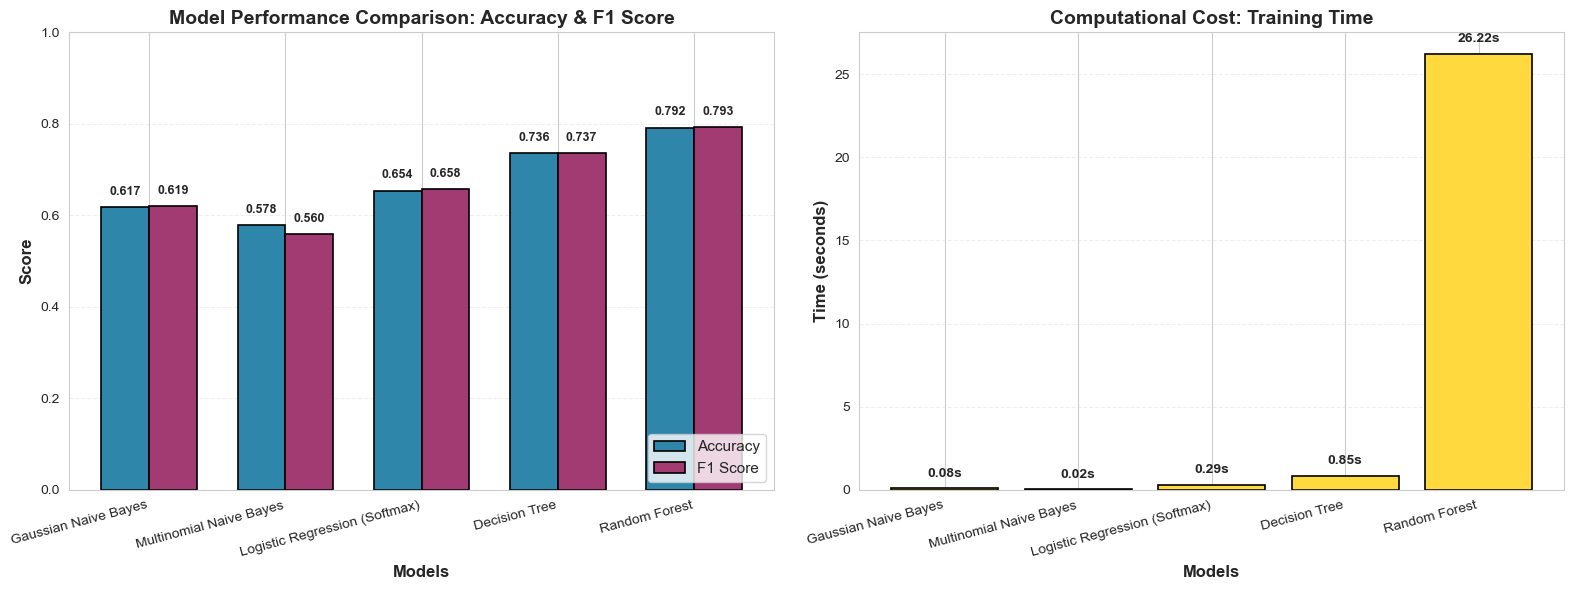

In [349]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(results_df))
width = 0.35

axes[0].bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', 
            color='#2E86AB', edgecolor='black', linewidth=1.2)
axes[0].bar(x + width/2, results_df['F1_Score'], width, label='F1 Score', 
            color='#A23B72', edgecolor='black', linewidth=1.2)

axes[0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance Comparison: Accuracy & F1 Score', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 1])

for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')
for i, v in enumerate(results_df['F1_Score']):
    axes[0].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

bars = axes[1].bar(results_df['Model'], results_df['Training_Time'], 
                   color='#FFD93D', edgecolor='black', linewidth=1.2)
axes[1].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Computational Cost: Training Time', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + max(results_df['Training_Time'])*0.02,
                f'{height:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

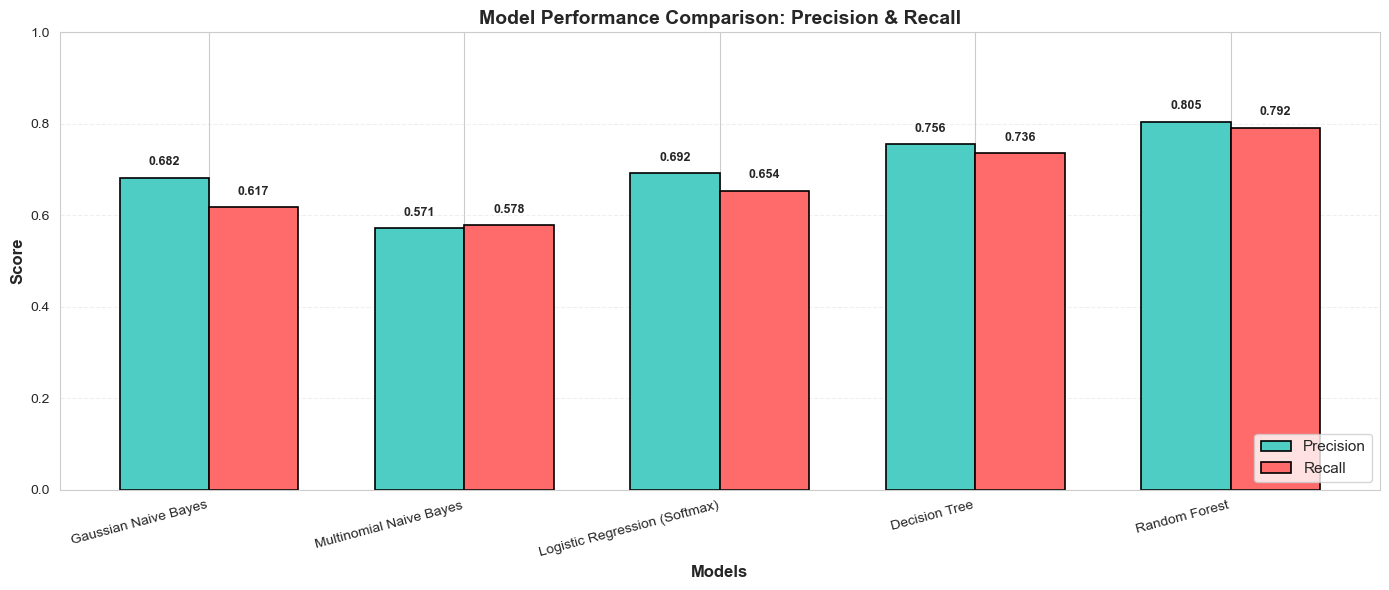


📊 Precision & Recall Summary:
Gaussian Naive Bayes           | Precision: 0.6825 | Recall: 0.6171
Multinomial Naive Bayes        | Precision: 0.5712 | Recall: 0.5779
Logistic Regression (Softmax)  | Precision: 0.6922 | Recall: 0.6540
Decision Tree                  | Precision: 0.7559 | Recall: 0.7357
Random Forest                  | Precision: 0.8050 | Recall: 0.7919


In [350]:
# Create merged bar plot for Precision and Recall comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_df))
width = 0.35

# Plot both Precision and Recall side-by-side
bars1 = ax.bar(x - width/2, results_df['Precision'], width, label='Precision', 
               color='#4ECDC4', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, results_df['Recall'], width, label='Recall', 
               color='#FF6B6B', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Precision & Recall', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1])

# Add value labels on bars for Precision
for i, v in enumerate(results_df['Precision']):
    ax.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Add value labels on bars for Recall
for i, v in enumerate(results_df['Recall']):
    ax.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Precision & Recall Summary:")
print("="*70)
for idx, row in results_df.iterrows():
    print(f"{row['Model']:30s} | Precision: {row['Precision']:.4f} | Recall: {row['Recall']:.4f}")

### 11.10 Best Model Summary

Identify and summarize the best performing model based on F1 score.

In [351]:
best_model_idx = results_df['F1_Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1_Score']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']

print("\n" + "="*70)
print("BEST MODEL IDENTIFIED")
print("="*70)
print(f"\n🏆 Winner: {best_model_name}")
print(f"\n📊 Performance Metrics:")
print(f"   • Accuracy:  {best_accuracy:.4f}")
print(f"   • F1 Score:  {best_f1:.4f}")
print(f"   • Precision: {results_df.loc[best_model_idx, 'Precision']:.4f}")
print(f"   • Recall:    {results_df.loc[best_model_idx, 'Recall']:.4f}")
print(f"\n⏱️  Training Time: {results_df.loc[best_model_idx, 'Training_Time']:.2f}s")
print("\n" + "="*70)
print("✅ MODELING COMPLETE - READY FOR DEPLOYMENT")
print("="*70)


BEST MODEL IDENTIFIED

🏆 Winner: Random Forest

📊 Performance Metrics:
   • Accuracy:  0.7919
   • F1 Score:  0.7928
   • Precision: 0.8050
   • Recall:    0.7919

⏱️  Training Time: 26.22s

✅ MODELING COMPLETE - READY FOR DEPLOYMENT


In [352]:
# ===== Retraining Random Forest with Top 15 Features =====\n
top_features_95 = importance_rf['Feature'].iloc[:features_for_95].tolist()

X_train_important = X_train[top_features_95]
X_test_important = X_test[top_features_95]

robust_scaler_important = RobustScaler()

X_train_important_scaled = robust_scaler_important.fit_transform(X_train_important)
X_test_important_scaled = robust_scaler_important.transform(X_test_important)

rf_params_important = {
    'n_estimators': [150, 200],
    'max_depth': [20, 25],
    'min_samples_split': [12, 15, 18],
    'min_samples_leaf': [4, 5, 6],
}

rf_important_results = train_and_evaluate(RandomForestClassifier(random_state=42, class_weight='balanced_subsample'), rf_params_important, 'Random Forest (15 Features)',
                                   X_train_important_scaled, y_train, X_test_important_scaled)


Training: Random Forest (15 Features)
Fitting 5 folds for each of 36 candidates, totalling 180 fits


KeyboardInterrupt: 

### 11.11 Feature Reduction Experiment

This section compares Random Forest performance using:
- All 20 selected features vs. Top features (those explaining 95% of importance)

**Purpose:**
- Evaluate if a simpler model with fewer features can maintain similar performance
- Reduce computational cost and model complexity
- Identify optimal feature subset for deployment

**Metrics Compared:**
- Accuracy, Precision, Recall, F1 Score
- Training Time
- Model complexity

In [ ]:
# Create comparison DataFrame for Random Forest models
rf_compare_df = pd.DataFrame({
    'Model': ['Random Forest (20 Features)', f'Random Forest ({features_for_95} Features)'],
    'Accuracy': [rf_results['Accuracy'], rf_important_results['Accuracy']],
    'Precision': [rf_results['Precision'], rf_important_results['Precision']],
    'Recall': [rf_results['Recall'], rf_important_results['Recall']],
    'F1_Score': [rf_results['F1_Score'], rf_important_results['F1_Score']],
    'Training_Time': [rf_results['Training_Time'], rf_important_results['Training_Time']]
})
rf_compare_df

In [ ]:
# Plot Accuracy, Precision, Recall, F1 Score, and Training Time for both models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'Training_Time']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(rf_compare_df))
width = 0.35
axes[0].bar(x - width/2, rf_compare_df['Accuracy'], width, label='Accuracy', color=PALETTE[0])
axes[0].bar(x + width/2, rf_compare_df['F1_Score'], width, label='F1 Score', color=PALETTE[1])
axes[0].set_xticks(x)
axes[0].set_xticklabels(rf_compare_df['Model'], rotation=15, ha='right')
axes[0].set_title('Accuracy & F1 Score')
axes[0].legend()
axes[1].bar(x - width/2, rf_compare_df['Precision'], width, label='Precision', color=PALETTE[3])
axes[1].bar(x + width/2, rf_compare_df['Recall'], width, label='Recall', color=PALETTE[4])
axes[1].set_xticks(x)
axes[1].set_xticklabels(rf_compare_df['Model'], rotation=15, ha='right')
axes[1].set_title('Precision & Recall')
axes[1].legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,4))
plt.bar(rf_compare_df['Model'], rf_compare_df['Training_Time'], color=PALETTE[2])
plt.title('Training Time Comparison')
plt.ylabel('Time (seconds)')
plt.show()